In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import Galactic, ICRS
from astropy import units as u
from modules.vr_opt import VrOpt
import time
from scipy.spatial import KDTree
import random
from scipy.sparse import lil_matrix
import nbimporter
import ensembleclustering as CE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from matplotlib.patches import Polygon

In [124]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

# Create 6D Gaussian data
np.random.seed(42) 
n = 1000
X_bg = (np.random.rand(n*5, 6) - 0.5) * 50 #background dataset of random points uniformly distributed 6D

mu = np.array([-5, 5, 5, 5, -5, 5]) #first 3 for average position of the Cluster in 3D(XYZ). Last 3 for average velocities in (VxVyVz)
c_xx = c_yy = 20 #Variance of the average in x and y.
c_xy = 15 # correlation of x and y, positive -> there is a correlation 
c_zz = 3 #Variance in z 
c_uvw = 1
cov = np.diag([c_xx, c_yy, c_zz, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy #makes positive correlation of x and y
# Add signal
X_sig_1 = np.random.multivariate_normal(mu, cov, n//2) #generate n/2 data points based on mu and cov

# Second cluster
mu_2 = np.array([5, -5, -5, -5, 5, -5])
c_xx_2 = c_yy = 20
c_xy_2 = -15
c_zz_2 = 3
cov = np.diag([c_xx_2, c_yy, c_zz_2, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy_2
X_sig_2 = np.random.multivariate_normal(mu_2, cov, n//2)

# Additional clusters' parameters
# Cluster 3
mu_3 = np.array([10, -10, -10, -10, 10, -10])
c_xx_3 = c_yy_3 = 25 # More spread in X-Y plane
c_xy_3 = 10
c_zz_3 = 4
cov_3 = np.diag([c_xx_3, c_yy_3, c_zz_3, c_uvw, c_uvw, c_uvw])
cov_3[0, 1] = cov_3[1, 0] = c_xy_3
X_sig_3 = np.random.multivariate_normal(mu_3, cov_3, n//2)

# Cluster 4
mu_4 = np.array([-7, -7, -7, -7, -7, -7])
c_xx_4 = c_yy_4 = 30
c_xy_4 = -12
c_zz_4 = 5
cov_4 = np.diag([c_xx_4, c_yy_4, c_zz_4, c_uvw, c_uvw, c_uvw])
cov_4[0, 1] = cov_4[1, 0] = c_xy_4
X_sig_4 = np.random.multivariate_normal(mu_4, cov_4, n//2)

# Cluster 5
mu_5 = np.array([2, -2, -2, 2, 2, 2])
c_xx_5 = c_yy_5 = 35
c_xy_5 = 8
c_zz_5 = 6
cov_5 = np.diag([c_xx_5, c_yy_5, c_zz_5, c_uvw, c_uvw, c_uvw])
cov_5[0, 1] = cov_5[1, 0] = c_xy_5
X_sig_5 = np.random.multivariate_normal(mu_5, cov_5, n//2)

X = np.concatenate([X_bg, X_sig_1, X_sig_2, X_sig_3, X_sig_4, X_sig_5], axis=0) #5000 bg stars, and 5*500 cluster stars
labels = np.concatenate([np.zeros(n*5), np.ones(n//2), np.ones(n//2)*2, np.ones(n//2)*3, np.ones(n//2)*4, np.ones(n//2)*5])

df = pd.DataFrame(X, columns=['x', 'y', 'z', 'vx', 'vy', 'vz'])
# Transform to spherical coordinates
gal_coords = Galactic(
    u=df.x.values * u.pc,
    v=df.y.values * u.pc,
    w=df.z.values * u.pc,
    # velocities UVW
    U=df.vx.values * u.km / u.s,
    V=df.vy.values * u.km / u.s,
    W=df.vz.values * u.km / u.s,
    representation_type="cartesian",
    # Velocity representation
    differential_type="cartesian",
)
# transform to ICRS
icrs_coords = gal_coords.transform_to(ICRS())
icrs_coords.representation_type = "spherical"

ra = icrs_coords.ra.value
dec = icrs_coords.dec.value
dist = icrs_coords.distance.value
pmra = icrs_coords.pm_ra.value * np.cos(np.deg2rad(dec))
pmdec = icrs_coords.pm_dec.value
rv_calc = icrs_coords.radial_velocity.value

df['ra'] = ra
df['dec'] = dec
df['dist'] = dist
df['pmra'] = pmra
df['pmdec'] = pmdec
df['radial_velocity'] = rv_calc

df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74

idx_cluster_1 = np.where(labels==1)[0]
idx_cluster_2 = np.where(labels==2)[0]
idx_cluster_3 = np.where(labels==3)[0]
idx_cluster_4 = np.where(labels==4)[0]
idx_cluster_5 = np.where(labels==5)[0]
idx_bg = np.where(labels==0)[0]

In [126]:
est = VrOpt(ra, dec, pmra, pmdec, dist)

# # Lower triangular matrix indices
a, b = np.tril_indices(len(X), -1)
_, _, delta_v = est.vr_opt(a, b)

# Create pairwise distance matrix with delta_v entries
dist_v_opt = np.zeros((len(X), len(X)))
dist_v_opt[a, b] = delta_v
dist_v_opt[b, a] = delta_v

# Compute semi-cohesion metric G
G = np.copy(dist_v_opt)
G = np.full_like(G, np.sum(G, axis=0)/len(G)) + np.full_like(G, np.sum(G, axis=0)/len(G)).T - np.sum(G)/len(G)**2 - G

# Functions from visualisations.py

In [128]:
def visualise_cluster_result(df, cluster_labels, true_labels, K, x_col, y_col, colors, alphas, zorders):

    # Subplots for each detected cluster
    fig, ax = plt.subplots(1, K, figsize=(5 * K, 5), sharex=True, sharey=True)

    if K == 1:
        ax = [ax]

    # Background settings
    background_color = colors[-1]
    background_alpha = alphas[-1]
    background_zorder = zorders[-1]

    # Cluster settings, exclude background parameters
    cluster_colors = colors[:-1]  
    cluster_alphas = alphas[:-1]  
    cluster_zorders = zorders[:-1]  

    for l_i, axis in enumerate(ax):
        
        idx_sel = cluster_labels == l_i  # Points assigned to current detected cluster

        # Plot true background points
        idx_background = (true_labels == 0) & idx_sel # Assuming 0 is background true label

        axis.scatter(
            df.loc[idx_background, x_col],
            df.loc[idx_background, y_col],
            s=3,
            alpha=background_alpha,
            zorder=background_zorder,
            c=background_color,
            label="Background"
        )

        # Plot points for cluster using true labels' colors
        for true_cluster_id in np.unique(true_labels):
            if true_cluster_id != 0:  # Skip background
                idx_true_cluster = (true_labels == true_cluster_id) & idx_sel
                axis.scatter(
                    df.loc[idx_true_cluster, x_col],
                    df.loc[idx_true_cluster, y_col],
                    s=3,
                    alpha=cluster_alphas[int(true_cluster_id) - 1],
                    zorder=cluster_zorders[int(true_cluster_id) - 1],
                    c=cluster_colors[int(true_cluster_id) - 1],  
                    label=f"True Cluster {int(true_cluster_id)}"
                )

        axis.set_xlabel(x_col, fontsize=15)
        axis.set_ylabel(y_col, fontsize=15)
        axis.set_title(f"Detected Cluster {l_i + 1}", fontsize=20)
        axis.legend(fontsize=12, markerscale = 4)

    plt.tight_layout()
    plt.show()

In [129]:
# Add partition lines for each node in KDTree in 2d plots

def add_partition_lines_2d(node, bounds, depth=0, lines=[]):

    if isinstance(node, KDTree.leafnode):
        return  # Stop at leaf nodes

    # Determine splitting dimension and value
    split_dim = depth % 2  # 0 for x-axis, 1 for y-axis
    split_val = node.split

    if split_dim == 0:  # Split along x-axis
        lines.append(((split_val, bounds[1][0]), (split_val, bounds[1][1])))  # vertical line
    elif split_dim == 1:  # Split along y-axis
        lines.append(((bounds[0][0], split_val), (bounds[0][1], split_val)))  # horizontal line

    # Update bounds for left and right children
    left_bounds = [bound.copy() for bound in bounds]
    right_bounds = [bound.copy() for bound in bounds]
    left_bounds[split_dim][1] = split_val
    right_bounds[split_dim][0] = split_val

    # Repeat for child nodes
    add_partition_lines_2d(node.less, left_bounds, depth + 1, lines)
    add_partition_lines_2d(node.greater, right_bounds, depth + 1, lines)

# Visualize  KDTree partitioning and dataset in 2D, showing points colored by their true labels
def visualise_kdtree_partition_2d(df, kd_tree, true_labels, colors, alphas, zorders):
  

    points = df[['x', 'y']].values

    # Background settings
    background_color = colors[-1]
    background_alpha = alphas[-1]
    background_zorder = zorders[-1]

    # Cluster settings
    cluster_colors = colors[:-1]
    cluster_alphas = alphas[:-1]
    cluster_zorders = zorders[:-1]

    # Map each label to its respective color, alpha, and zorder
    unique_labels = np.unique(true_labels)
    label_to_color = {}
    label_to_alpha = {}
    label_to_zorder = {}

    for i, label in enumerate(unique_labels):
        if label == 0:  # Background
            label_to_color[label] = background_color
            label_to_alpha[label] = background_alpha
            label_to_zorder[label] = background_zorder
        else:  # Clusters
            cluster_idx = (i - 1) % len(cluster_colors)
            label_to_color[label] = cluster_colors[cluster_idx]
            label_to_alpha[label] = cluster_alphas[cluster_idx]
            label_to_zorder[label] = cluster_zorders[cluster_idx]

    fig, ax = plt.subplots(figsize=(10, 10))

    for label in unique_labels:
        idx = true_labels == label
        ax.scatter(
            points[idx, 0],
            points[idx, 1],
            s=10,
            color=label_to_color[label],
            alpha=label_to_alpha[label],
            zorder=label_to_zorder[label],
            label=f'Cluster {int(label)}' if label != 0 else 'Background'
        )

    # Add partition lines
    bounds = [
        [points[:, 0].min(), points[:, 0].max()],
        [points[:, 1].min(), points[:, 1].max()],
    ]
    lines = []
    add_partition_lines_2d(kd_tree.tree, bounds, lines=lines)

    for line in lines:
        (x_start, y_start), (x_end, y_end) = line
        ax.plot([x_start, x_end], [y_start, y_end], color='black', alpha=1, linestyle='--', linewidth=2, zorder=0)

    # Number of partitions = number of lines
    num_partitions = len(lines)

    ax.set_title(f'KDTree Partitioning in 2D with Real Labels\nNumber of Partitions: {num_partitions + 1}', fontsize=16)
    ax.set_xlabel('X', fontsize=14)
    ax.set_ylabel('Y', fontsize=14)
    ax.legend(fontsize=12)
    plt.show()

# Part of initial algorithm with KDTree, softmax

In [131]:
def softmax_clustering_optimized(Gamma, K, theta=0.01, epsilon=0.001, max_iter=1000, initial_partition=None):

    start_time = time.time()

    # Set g[i,i] = 0 for all i
    np.fill_diagonal(Gamma, 0)
    n = Gamma.shape[0]

    np.random.seed(42)

    # Use the initial partition if provided, otherwise initialize randomly
    if initial_partition is not None:
        p_i = initial_partition
    else:
        p_i = np.random.dirichlet(np.ones(K), size=n)

    z = np.zeros((n, K))  # for covariance

    for iteration in range(max_iter):
        # Compute covaraince (z)for all points and clusters
        
        z = Gamma @ p_i 
        # Stabilize softmax computation
        z_max = np.max(theta * z, axis=1, keepdims=True) 
        p_t = np.exp(theta * z - z_max) * p_i  

        #p_t = np.exp(theta * z) * p_i  # Softmax function
        p_i = p_t / (np.sum(p_t, axis=1, keepdims=True) + 1e-10)  # Update probability uisng softmax function and normalize it (it must sum to 1)

        theta += epsilon

         # If pi changes insignificantly, stop
        if iteration > 0 and np.allclose(p_i, prev_pi, atol=1e-6):
            break

        prev_pi = p_i.copy()
        
    execution_time = time.time() - start_time
    #print(f'Execution time (softmax): {int(execution_time // 60)} minutes, {int(execution_time % 60)} seconds and {int((execution_time % 1) * 1000)} ms')
    #print(f'Number of iterations (softmax): {iteration + 1}')

    return p_i, z

In [132]:
# get clusters from probability
def get_clusters(p_i):

    cluster_labels = np.argmax(p_i, axis=1)
    _, relabeled_clusters = np.unique(cluster_labels, return_inverse=True)
    
    return relabeled_clusters

In [133]:
class TreeNode:
    def __init__(self, kd_node, point_indices):
        self.kd_node = kd_node
        self.point_indices = point_indices
        self.left = None
        self.right = None
        self.cluster = set(point_indices)

# Traverse kdtree and extract only its leaf nodes
def extract_leaf_nodes(kd_node, point_indices, points, node_indices, point_in_node):
  
    if isinstance(kd_node, KDTree.leafnode):
        unique_indices = np.setdiff1d(point_indices, list(point_in_node.keys()), assume_unique=True)
        if len(unique_indices) > 0:
            node_indices.append(unique_indices)
            point_in_node.update({idx: len(node_indices) - 1 for idx in unique_indices})
    else:
        split_dim = kd_node.split_dim
        split_val = kd_node.split
        left_indices = point_indices[points[point_indices, split_dim] <= split_val]
        right_indices = point_indices[points[point_indices, split_dim] > split_val]

        extract_leaf_nodes(kd_node.less, left_indices, points, node_indices, point_in_node)
        extract_leaf_nodes(kd_node.greater, right_indices, points, node_indices, point_in_node)

# Compute semi-cohesion G matrix
def compute_g_matrix(dist_matrix):

    G = np.full_like(dist_matrix, np.sum(dist_matrix, axis=0)/len(dist_matrix)) + np.full_like(dist_matrix, np.sum(dist_matrix, axis=0)/len(dist_matrix)).T - np.sum(dist_matrix)/len(dist_matrix)**2 - dist_matrix
    return G

def prepare_kdtree(df, leafsize=300):
    points = df[['x', 'y', 'z']].values
    kd_tree = KDTree(points, leafsize=leafsize)

    node_indices = []
    point_in_node = {}
    extract_leaf_nodes(kd_tree.tree, np.arange(len(points)), points, node_indices, point_in_node)
    return kd_tree, node_indices, point_in_node

# Consensus clustering, cutting space (using kdtree), dataset rotation

In [141]:
def rotate_dataset(df, angle_deg, axis='z'):
    angle_rad = np.radians(angle_deg)
    if axis == 'x':
        rotation_matrix = np.array([
            [1, 0, 0],
            [0, np.cos(angle_rad), -np.sin(angle_rad)],
            [0, np.sin(angle_rad), np.cos(angle_rad)]
        ])
    elif axis == 'y':
        rotation_matrix = np.array([
            [np.cos(angle_rad), 0, np.sin(angle_rad)],
            [0, 1, 0],
            [-np.sin(angle_rad), 0, np.cos(angle_rad)]
        ])
    elif axis == 'z':
        rotation_matrix = np.array([
            [np.cos(angle_rad), -np.sin(angle_rad), 0],
            [np.sin(angle_rad), np.cos(angle_rad), 0],
            [0, 0, 1]
        ])
    else:
        raise ValueError("Axis must be 'x', 'y', or 'z'.")

    points = df[['x', 'y', 'z']].values
    rotated_points = points @ rotation_matrix.T
    rotated_df = df.copy()
    rotated_df[['x', 'y', 'z']] = rotated_points
    return rotated_df

In [143]:
def rotate_and_cluster_softmax(df, dist_matrix, K, clustering_func, true_labels, colors, alphas, zorders, num_rotations=3, axis='z', print_info = False):
    angle_increment = 360 / num_rotations
    all_results = []  # clustering results for each rotation

    for i in range(num_rotations):
        angle = i * angle_increment
        print(f"Rotating dataset by {angle} degrees around {axis} axis")
        
        # Rotate dataset
        rotated_df = rotate_dataset(df, angle, axis=axis)

        # Prepare kdtree and extract leaves
        kd_tree, node_indices, point_in_node = prepare_kdtree(rotated_df)

        G = compute_g_matrix(dist_matrix)

        label_offset = 0
        rotation_results = []

        # Run softmax clustering for each leaf
        for leaf_idx, indices in enumerate(node_indices):
            subset_G = G[np.ix_(indices, indices)]  # subset of G for current leaf
            p_i, _ = clustering_func(subset_G, K)  # softmax clustering

            # Convert cluster labels to start from 0
            raw_cluster_labels = np.argmax(p_i, axis=1)
            unique_labels = np.unique(raw_cluster_labels)

            label_mapping = {}
            for new_label, old_label in enumerate(unique_labels):
                label_mapping[old_label] = new_label
            
            adjusted_labels = []
            for label in raw_cluster_labels:
                adjusted_labels.append(label_mapping[label])

            adjusted_labels = np.array(adjusted_labels)

            # Offset cluster labels
            cluster_labels = adjusted_labels + label_offset
            label_offset += len(unique_labels)  # update offset for next leaf

            # Save results
            rotation_results.append((cluster_labels, indices))

            if print_info == True:
                print(f"Rotation {i + 1}, Leaf {leaf_idx + 1}:")
                print(f"  Number of clusters: {len(unique_labels)}")
                print(f"  Cluster labels: {np.unique(cluster_labels)}")

        all_results.append((angle, rotation_results))

        # plotting; just for checking
        if i == 0 or i == 1:
            visualise_kdtree_partition_2d(rotated_df, kd_tree, true_labels, colors, alphas, zorders)

    return all_results

In [145]:
# Extract clustering labels for all points across all rotations
def extract_labels_from_results(cluster_results):
    all_labels = []

    for angle, results in cluster_results:
        # total number of points
        num_points = max(max(indices) for _, indices in results) + 1
        rotation_labels = np.full(num_points, -1, dtype=int)  # -1 for unlabeled points

        for labels, indices in results:
            rotation_labels[indices] = labels

        all_labels.append(rotation_labels)

    return np.array(all_labels)

In [147]:
def consensus_clustering_from_rotations(cluster_results, solver='hbgf', nclass=None, random_state=None, verbose=False):
    
    # Extract labels from clustering results
    all_labels = extract_labels_from_results(cluster_results)
    print("Shape of all_labels:", all_labels.shape)
    print("Sample labels from rotations:\n", all_labels[:5])

    # Consensus clustering
    label_ce = CE.cluster_ensembles(all_labels, nclass=nclass, solver=solver, random_state=random_state, verbose=verbose)

    return label_ce

Rotating dataset by 0.0 degrees around z axis


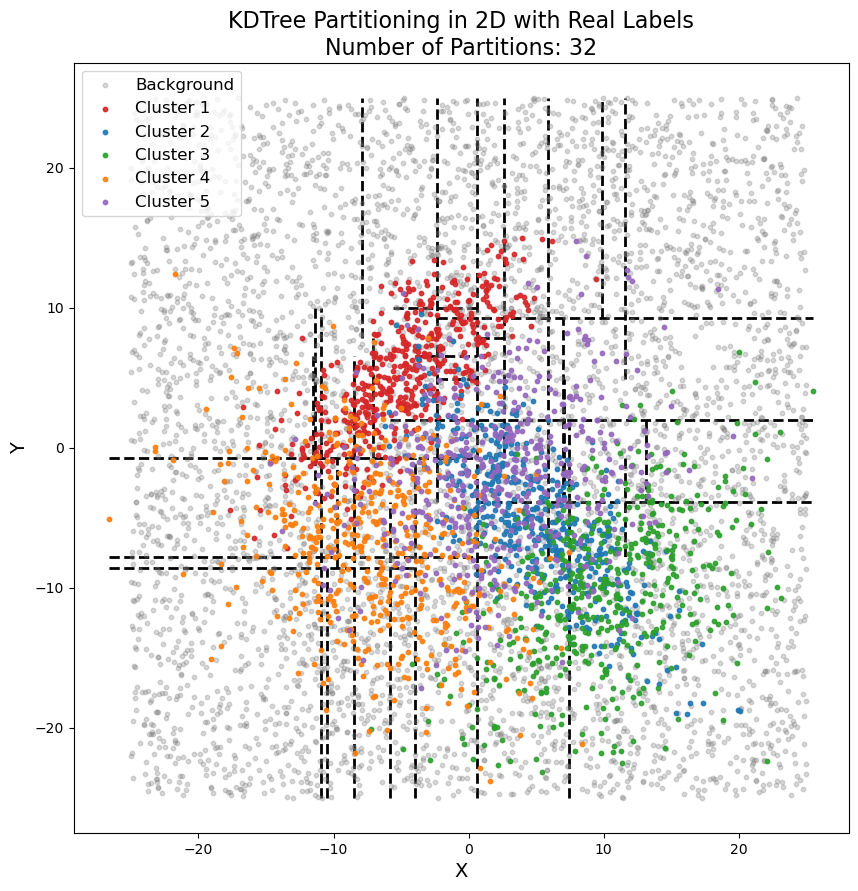

Rotating dataset by 180.0 degrees around z axis


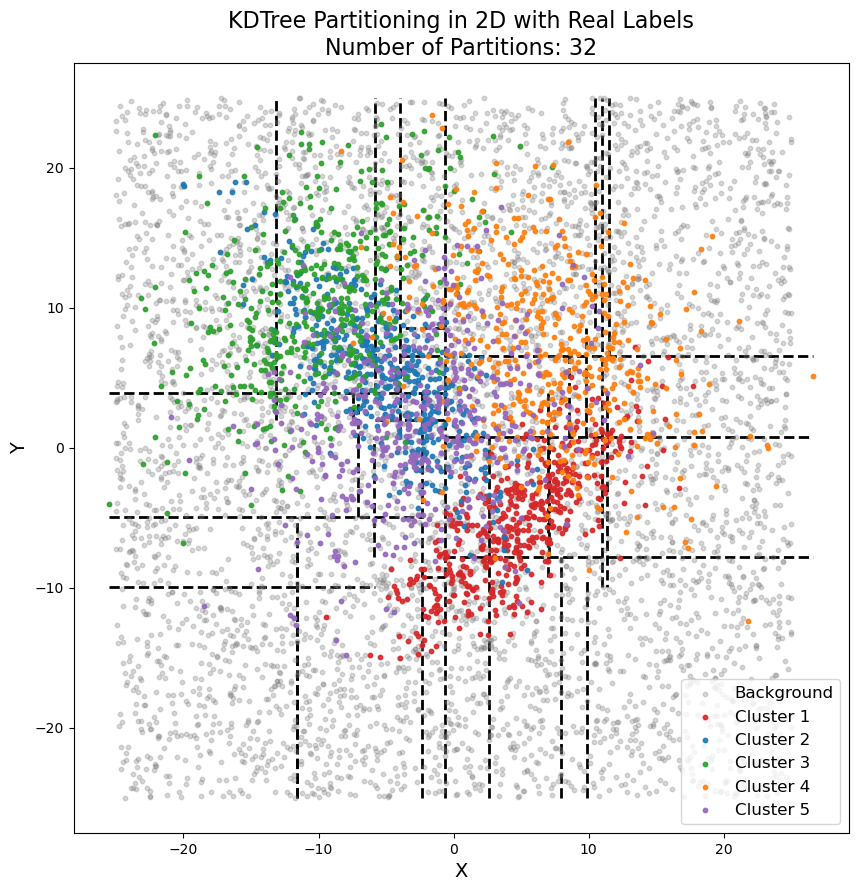

In [149]:
K = 9
num_rotations = 2
axis = 'z'

# set print_info to True to print iformation about each rotation and each grid
cluster_results = rotate_and_cluster_softmax(df, dist_v_opt, K, softmax_clustering_optimized, labels, colors, alphas, zorders, num_rotations=num_rotations, axis=axis, print_info=False)

In [150]:
consensus_labels = consensus_clustering_from_rotations(cluster_results, solver='hgpa', nclass = 9, random_state=42, verbose=True)

Shape of all_labels: (2, 7500)
Sample labels from rotations:
 [[ 60  54  69 ... 104  19  76]
 [ 80  81  31 ...   5 106  48]]
Cluster Ensembles
    - number of classes: 9
    - solver: hgpa
    - length of base clustering labels: 7500
    - number of base clusters: 2


In [151]:
#  Compute NMI between consensus clustering and true labels, ignoring background points
def calculate_nmi(consensus_labels, true_labels, background_label=0):
   
    non_background_indices = true_labels != background_label
    filtered_true_labels = true_labels[non_background_indices]
    filtered_consensus_labels = consensus_labels[non_background_indices]

    true_labels_encoded = LabelEncoder().fit_transform(filtered_true_labels)
    consensus_labels_encoded = LabelEncoder().fit_transform(filtered_consensus_labels)

    nmi = normalized_mutual_info_score(true_labels_encoded, consensus_labels_encoded)

    #print(f"NMI (ignoring background points): {nmi:.4f}")
    return nmi

In [152]:
nmi = calculate_nmi(consensus_labels, labels, background_label=0)

In [153]:
def calculate_nmi_and_purity(consensus_labels, true_labels, background_label=0):
    
    # Filter out background points
    non_background_indices = true_labels != background_label
    filtered_true_labels = true_labels[non_background_indices]
    filtered_consensus_labels = consensus_labels[non_background_indices]

    # Encode labels
    true_labels_encoded = LabelEncoder().fit_transform(filtered_true_labels)
    consensus_labels_encoded = LabelEncoder().fit_transform(filtered_consensus_labels)

    overall_nmi = normalized_mutual_info_score(true_labels_encoded, consensus_labels_encoded)
    print(f"Overall NMI (ignoring background points): {overall_nmi:.4f}\n")

    results_df = pd.DataFrame({
        'Consensus label': consensus_labels,
        'True label': true_labels
    })

    # Purity calculation for each cluster
    total_points = len(filtered_true_labels)
    overall_purity_sum = 0

    for cluster_label, cluster_data in results_df.groupby('Consensus label'):
        cluster_true_labels = cluster_data['True label'].values
        cluster_size = len(cluster_true_labels)

        # Exclude background points
        non_background_cluster_indices = cluster_true_labels != background_label
        cluster_true_labels_no_background = cluster_true_labels[non_background_cluster_indices]

        if len(cluster_true_labels_no_background) == 0:
            print(f"Cluster {cluster_label}: Only background points present.")
            print(f"  - Number of points: {cluster_size}\n")
            continue

        most_common_true_label_count = pd.Series(cluster_true_labels_no_background).value_counts().max()
        purity = most_common_true_label_count / len(cluster_true_labels_no_background)
        overall_purity_sum += most_common_true_label_count

        print(f"Cluster {cluster_label}:")
        print(f"  - Number of points: {cluster_size}")
        print(f"  - Purity (excluding background): {purity:.4f}")

        true_label_counts = pd.Series(cluster_true_labels).value_counts().sort_index()
        print(f"  - True label distribution in this cluster:")
        for true_label, count in true_label_counts.items():
            label_info = "Background noise" if true_label == background_label else f"True label {true_label}"
            print(f"    * {label_info}: {count} points")

        print("\n") 
        
    return overall_nmi

In [154]:
overall_nmi = calculate_nmi_and_purity(consensus_labels, labels, background_label=0)

Overall NMI (ignoring background points): 0.4143

Cluster 0:
  - Number of points: 824
  - Purity (excluding background): 0.4113
  - True label distribution in this cluster:
    * Background noise: 260 points
    * True label 2.0: 230 points
    * True label 3.0: 26 points
    * True label 4.0: 232 points
    * True label 5.0: 76 points


Cluster 1:
  - Number of points: 825
  - Purity (excluding background): 0.4796
  - True label distribution in this cluster:
    * Background noise: 531 points
    * True label 2.0: 29 points
    * True label 3.0: 50 points
    * True label 4.0: 141 points
    * True label 5.0: 74 points


Cluster 2:
  - Number of points: 842
  - Purity (excluding background): 0.7071
  - True label distribution in this cluster:
    * Background noise: 644 points
    * True label 1.0: 58 points
    * True label 5.0: 140 points


Cluster 3:
  - Number of points: 842
  - Purity (excluding background): 0.5429
  - True label distribution in this cluster:
    * Background no

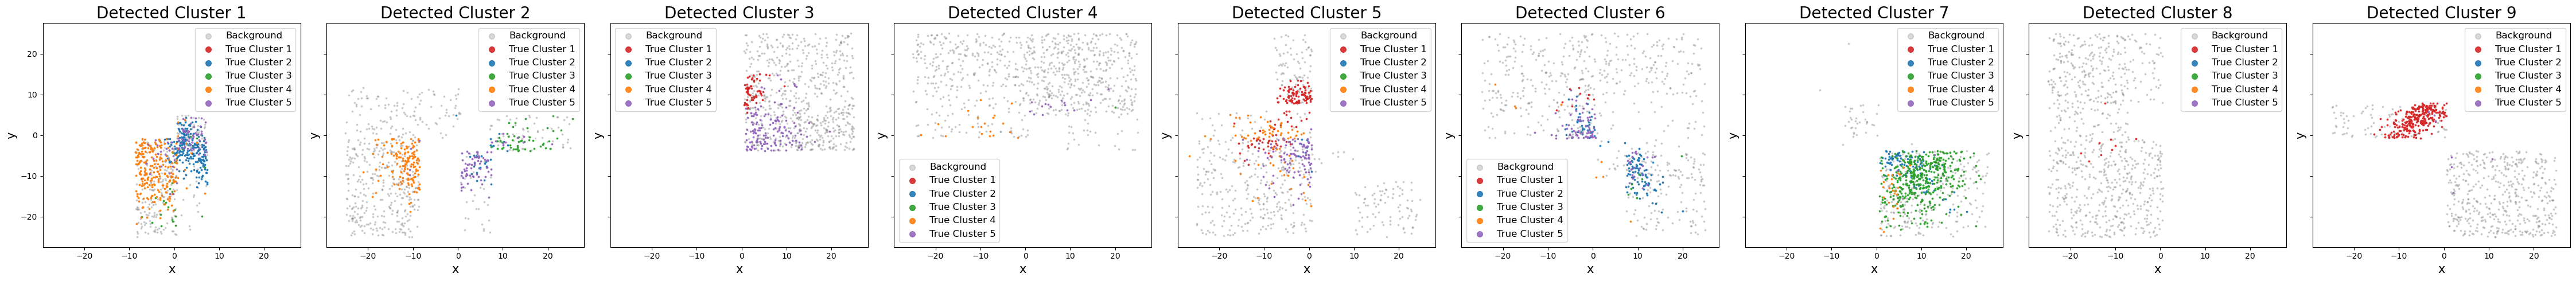

In [155]:
visualise_cluster_result(
    df=df,
    cluster_labels=consensus_labels,
    true_labels=labels,
    K=len(np.unique(consensus_labels)),  
    x_col='x',
    y_col='y',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

# Different approach 
# Consensus clustering, cutting space (using square grid), grid shift, dataset rotation

In [157]:
# Shift grid by vector
def shift_grid(x_range, y_range, z_range, shift_vector):
   
    dx, dy, dz = shift_vector
    return x_range + dx, y_range + dy, z_range + dz

In [166]:
# Create extended grid to ensure it covers all points, even after shifts
def create_grid(df, grid_size, shift_vector, num_shifts):

    # min and max ranges for x, y, z
    x_min, x_max = df['x'].min(), df['x'].max()
    y_min, y_max = df['y'].min(), df['y'].max()
    z_min, z_max = df['z'].min(), df['z'].max()

    # Maximum extent required for grid
    dx, dy, dz = shift_vector
    x_min_extended = x_min - abs(dx) * num_shifts
    x_max_extended = x_max + abs(dx) * num_shifts
    y_min_extended = y_min - abs(dy) * num_shifts
    y_max_extended = y_max + abs(dy) * num_shifts
    z_min_extended = z_min - abs(dz) * num_shifts
    z_max_extended = z_max + abs(dz) * num_shifts

    # Grid ranges
    x_range = np.arange(x_min_extended, x_max_extended + grid_size, grid_size)
    y_range = np.arange(y_min_extended, y_max_extended + grid_size, grid_size)
    z_range = np.arange(z_min_extended, z_max_extended + grid_size, grid_size)

    return x_range, y_range, z_range

In [168]:
def plot_grid_with_dataset(df, x_range, y_range, z_range, true_labels, colors, alphas, zorders, projection='xy', title="Dataset with grid"):

    # Select axes based on projection
    if projection == 'xy':
        points = df[['x', 'y']].values
        grid_x = x_range
        grid_y = y_range
        axis_labels = ('X-axis', 'Y-axis')
    elif projection == 'xz':
        points = df[['x', 'z']].values
        grid_x = x_range
        grid_y = z_range
        axis_labels = ('X-axis', 'Z-axis')
    elif projection == 'yz':
        points = df[['y', 'z']].values
        grid_x = y_range
        grid_y = z_range
        axis_labels = ('Y-axis', 'Z-axis')
    else:
        raise ValueError("Projection must be one of 'xy', 'xz', 'yz'")

    # labels to integers
    true_labels = true_labels.astype(int)

    # Background
    background_color = colors[-1]
    background_alpha = alphas[-1]
    background_zorder = zorders[-1]

    # Clusters
    cluster_colors = colors[:-1]
    cluster_alphas = alphas[:-1]
    cluster_zorders = zorders[:-1]

    # Map labels
    unique_labels = np.unique(true_labels)
    label_to_color = {}
    label_to_alpha = {}
    label_to_zorder = {}

    for label in unique_labels:
        if label == 0:  # Background
            label_to_color[label] = background_color
            label_to_alpha[label] = background_alpha
            label_to_zorder[label] = background_zorder
        else:  # Clusters
            cluster_idx = (label - 1) % len(cluster_colors)
            label_to_color[label] = cluster_colors[cluster_idx]
            label_to_alpha[label] = cluster_alphas[cluster_idx]
            label_to_zorder[label] = cluster_zorders[cluster_idx]

    fig, ax = plt.subplots(figsize=(10, 10))

    # Dataset points
    for label in unique_labels:
        idx = true_labels == label
        ax.scatter(
            points[idx, 0],
            points[idx, 1],
            s=10,
            color=label_to_color[label],
            alpha=label_to_alpha[label],
            zorder=label_to_zorder[label],
            label=f'Label {label}'
        )

    # Grid lines
    for x in grid_x:
        ax.plot([x, x], [grid_y[0], grid_y[-1]], color='black', alpha=0.5, linestyle='--', linewidth=1, zorder=0)
    for y in grid_y:
        ax.plot([grid_x[0], grid_x[-1]], [y, y], color='black', alpha=0.5, linestyle='--', linewidth=1, zorder=0)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.legend(fontsize=12)
    plt.show()

In [170]:
def partition_points_into_grid(df, x_range, y_range, z_range):

    grid_partitions = {}

    for i, point in df[['x', 'y', 'z']].iterrows():
        x, y, z = point
        # Determine which cell point belongs to
        cell = (
            np.digitize(x, x_range) - 1,
            np.digitize(y, y_range) - 1,
            np.digitize(z, z_range) - 1
        )
        if cell not in grid_partitions:
            grid_partitions[cell] = []
        grid_partitions[cell].append(i)

    return grid_partitions

In [172]:
def grid_softmax_clustering(df, dist_matrix, grid_size, shift_vector, K, clustering_func, true_labels, colors, num_rotations=3, rotation_axis='z', rotation_angle=None, num_shifts=3, projection='xy', print_info = False):
 
    all_results = []
    original_dataset_size = len(df)

    if rotation_angle is None:
        rotation_angle = 360 / num_rotations if num_rotations > 1 else 0

    for rotation_step in range(num_rotations):
        print(f"Rotation {rotation_step + 1}: {'No rotation' if rotation_step == 0 else f'Rotating by {rotation_step * rotation_angle:.2f}° around {rotation_axis}-axis'}")
        rotated_df = df.copy() if rotation_step == 0 else rotate_dataset(df, rotation_step * rotation_angle, axis=rotation_axis)
        rotated_indices = np.arange(original_dataset_size)

        G = compute_g_matrix(dist_matrix)

        # Initialize grid ranges
        x_range, y_range, z_range = create_grid(rotated_df, grid_size, shift_vector, num_shifts)

        for shift_step in range(num_shifts):
            print(f"  Shift {shift_step + 1}: Applying shift vector {shift_vector}")
            
            # Reset label_offset for each shift to start from 0
            label_offset = 0
            
            # Partition points into grid cells
            grid_partitions = partition_points_into_grid(rotated_df, x_range, y_range, z_range)
            shift_results = []

            for cell_idx, (cell, indices) in enumerate(grid_partitions.items()):
                if len(indices) == 0:
                    continue  # Skip empty cells

                original_indices = rotated_indices[indices]
               
                original_indices = original_indices[original_indices < G.shape[0]]
                

                subset_G = G[np.ix_(original_indices, original_indices)]
                p_i, _ = clustering_func(subset_G, K)

                # Get labels from softmax
                softmax_cluster_labels = np.argmax(p_i, axis=1)
                
                # Map labels from softmax to sequential labels starting from label_offset
                unique_seq_labels = np.unique(softmax_cluster_labels)

                label_mapping = {}
                for new_label, old_label in enumerate(unique_seq_labels):
                    label_mapping[old_label] = new_label + label_offset

                # Map labels
                cluster_labels = []
                for label in softmax_cluster_labels:
                    cluster_labels.append(label_mapping[label])
                cluster_labels = np.array(cluster_labels)

                # Increment label_offset based on number of unique clusters in this cell
                label_offset += len(unique_seq_labels)

                # Results for current cell
                shift_results.append((cluster_labels, original_indices))

                if print_info == True:
                    print(f"    Rotation {rotation_step + 1}, Shift {shift_step + 1}, Cell {cell_idx + 1}:")
                    print(f"      Number of clusters: {len(unique_seq_labels)}")
                    print(f"      Cluster labels: {np.unique(cluster_labels)}")

            # Results for this grid shift
            all_results.append((rotation_step, shift_step, shift_results))

            # visualizations; just for checking
            if (rotation_step == 0 or rotation_step == 1) and shift_step == 0: 
                plot_grid_with_dataset(
                    rotated_df, x_range, y_range, z_range, true_labels, colors, alphas, zorders,
                    projection=projection, title=f"Rotation {rotation_step + 1}, Grid Shift {shift_step + 1}"
                )

            # Shift grid for next iteration
            x_range, y_range, z_range = shift_grid(x_range, y_range, z_range, shift_vector)

    return all_results

In [174]:
def extract_labels_from_grid(grid_results):

    all_labels = []

    for rotation_step, shift_step, shift_results in grid_results:
        if not shift_results: 
            continue

        # Initialize grid_labels
        try:
            max_index = -1
            for _, indices in shift_results:
                if len(indices) > 0:  # Ensure list is not empty
                    max_index = max(max_index, max(indices))

            #total number of points
            num_points = max_index + 1
        except ValueError:
            print(f"Shift results are empty for rotation {rotation_step + 1}, shift {shift_step + 1}")
            continue

        grid_labels = np.full(num_points, -1, dtype=int)  # -1 for unlabeled points

        for cluster_labels, indices in shift_results:
            if len(indices) == 0:  # Skip empty clusters
                continue
            grid_labels[indices] = cluster_labels  # Assign cluster labels

        all_labels.append(grid_labels)

    if not all_labels:
        raise ValueError("No valid clustering results found in grid results.")

    return np.array(all_labels)

In [176]:
# consensus clustering on labels extracted from grid results
def consensus_clustering_from_grid(grid_results, solver='hbgf', nclass=None, random_state=None, verbose=False):
    
    # Extract labels from clustering results
    all_labels = extract_labels_from_grid(grid_results)

    # consensus clustering
    consensus_labels = CE.cluster_ensembles(all_labels, nclass=nclass, solver=solver, random_state=random_state, verbose=verbose)
    return consensus_labels

Rotation 1: No rotation
  Shift 1: Applying shift vector [3, 3, 3]


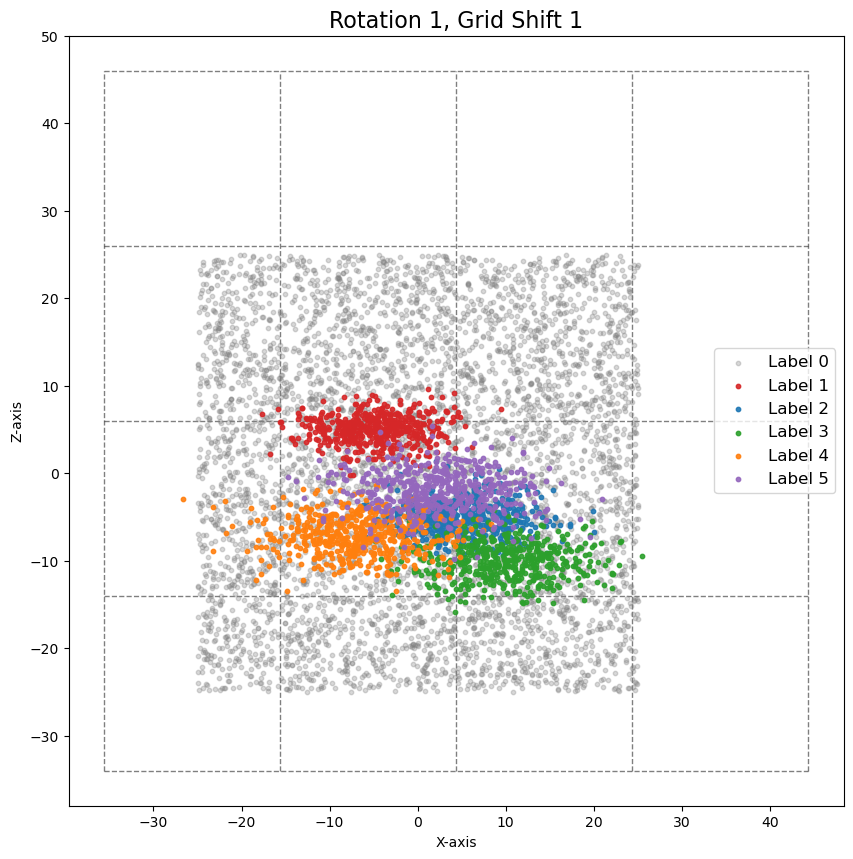

  Shift 2: Applying shift vector [3, 3, 3]
  Shift 3: Applying shift vector [3, 3, 3]
Rotation 2: Rotating by 30.00° around z-axis
  Shift 1: Applying shift vector [3, 3, 3]


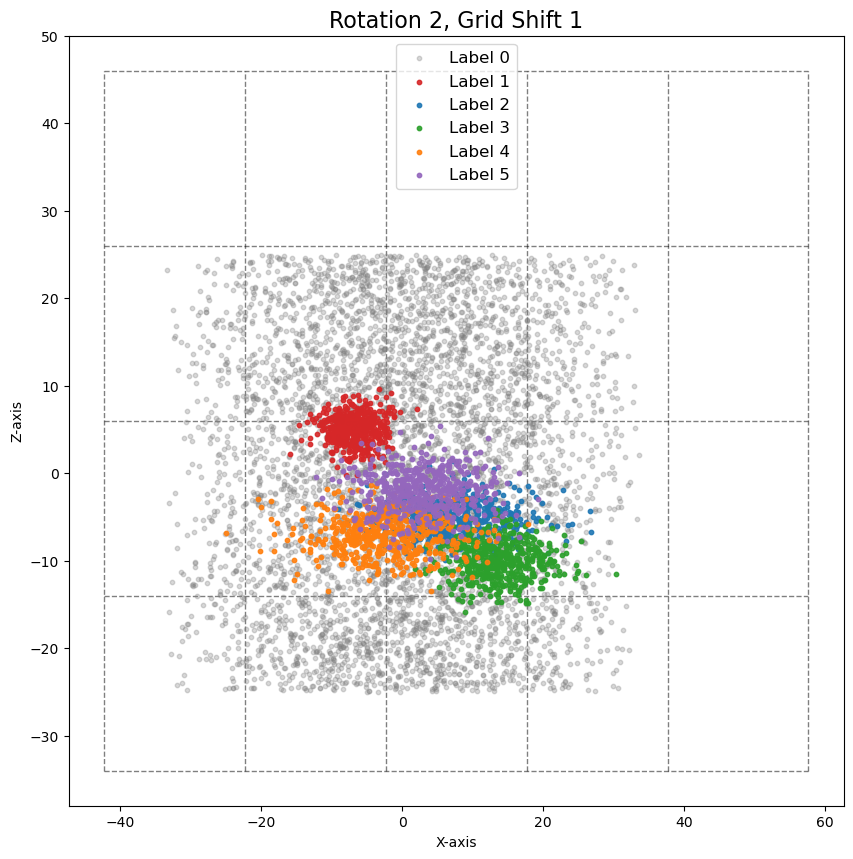

  Shift 2: Applying shift vector [3, 3, 3]
  Shift 3: Applying shift vector [3, 3, 3]
Rotation 3: Rotating by 60.00° around z-axis
  Shift 1: Applying shift vector [3, 3, 3]
  Shift 2: Applying shift vector [3, 3, 3]
  Shift 3: Applying shift vector [3, 3, 3]


In [178]:
grid_size = 20 #10
shift_vector = [3,3,3] #[2, 2, 2]
num_rotations = 3 #2
rotation_axis = 'z'
rotation_angle = 30# None
num_shifts = 3 #2
projection = 'xz'
K = 9
dist_matrix = dist_v_opt

# set print_info to True to print iformation about each rotation and each grid
grid_results = grid_softmax_clustering(df, dist_matrix, grid_size, shift_vector, K, softmax_clustering_optimized, labels, colors, num_rotations, rotation_axis, rotation_angle, num_shifts, projection)


In [179]:
K = 9
consensus_labels = consensus_clustering_from_grid(grid_results, solver='nmf', nclass=K, random_state=42, verbose=True)

Cluster Ensembles
    - number of classes: 9
    - solver: nmf
    - length of base clustering labels: 7500
    - number of base clusters: 9


In [181]:
calculate_nmi(consensus_labels, labels, background_label=0)

0.49316379819494727

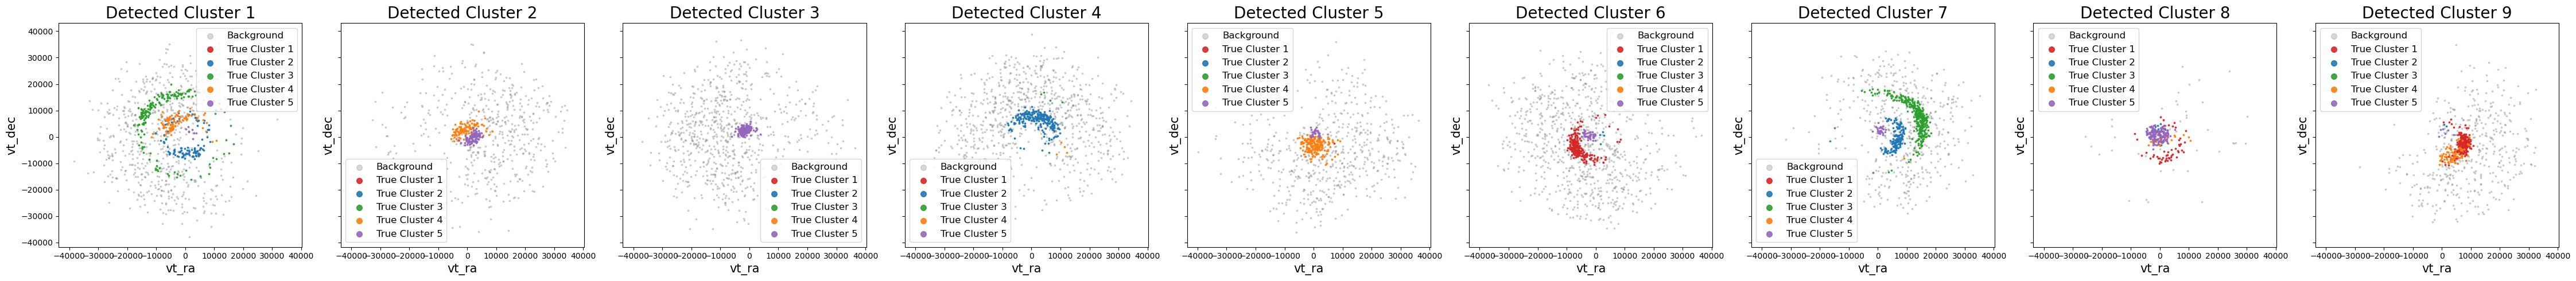

In [184]:
visualise_cluster_result(
    df=df,
    cluster_labels=consensus_labels,
    true_labels=labels,
    K=len(np.unique(consensus_labels)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

# Visualise two grids on one plot to see how they move

In [40]:
# dataset with two grids on the same plot
def plot_multiple_grids_with_dataset_2d(df, x_range1, y_range1, z_range1, x_range2, y_range2, z_range2, true_labels, colors, alphas, zorders, projection='xy', title="Dataset with original and shifted grid"):

    if projection == 'xy':
        x_col, y_col = 'x', 'y'
        grid1_ranges = (x_range1, y_range1)
        grid2_ranges = (x_range2, y_range2)
    elif projection == 'yz':
        x_col, y_col = 'y', 'z'
        grid1_ranges = (y_range1, z_range1)
        grid2_ranges = (y_range2, z_range2)
    elif projection == 'xz':
        x_col, y_col = 'x', 'z'
        grid1_ranges = (x_range1, z_range1)
        grid2_ranges = (x_range2, z_range2)
    else:
        raise ValueError("Invalid projection. Use 'xy', 'yz', or 'xz'.")

    # Map labels
    unique_labels = np.unique(true_labels)
    label_to_color = {}
    label_to_alpha = {}
    label_to_zorder = {}

    background_color = colors[-1]
    background_alpha = alphas[-1]
    background_zorder = zorders[-1]

    cluster_colors = colors[:-1]
    #cluster_alphas = alphas[:-1]
    cluster_alphas = [0.6] * (len(colors) - 1)
    cluster_zorders = zorders[:-1]

    for i, label in enumerate(unique_labels):
        if label == 0:  # Background
            label_to_color[label] = background_color
            label_to_alpha[label] = background_alpha
            label_to_zorder[label] = background_zorder
        else:  # Clusters
            cluster_idx = (i - 1) % len(cluster_colors)
            label_to_color[label] = cluster_colors[cluster_idx]
            label_to_alpha[label] = cluster_alphas[cluster_idx]
            label_to_zorder[label] = cluster_zorders[cluster_idx]

    fig, ax = plt.subplots(figsize=(10, 10))
    points = df[[x_col, y_col]].values

    for label in unique_labels:
        idx = true_labels == label
        ax.scatter(
            points[idx, 0],
            points[idx, 1],
            s=10,
            color=label_to_color[label],
            alpha=label_to_alpha[label],
            zorder=label_to_zorder[label],
            label=f"Cluster {int(label)}" if label != 0 else "Background"
        )

    # Add first grid
    for x in grid1_ranges[0]:
        ax.plot([x, x], [grid1_ranges[1][0], grid1_ranges[1][-1]], color='magenta', linestyle='--', alpha=1)
    for y in grid1_ranges[1]:
        ax.plot([grid1_ranges[0][0], grid1_ranges[0][-1]], [y, y], color='magenta', linestyle='--', alpha=1)

    # Add second grid
    for x in grid2_ranges[0]:
        ax.plot([x, x], [grid2_ranges[1][0], grid2_ranges[1][-1]], color='black', linestyle='--', alpha=1)
    for y in grid2_ranges[1]:
        ax.plot([grid2_ranges[0][0], grid2_ranges[0][-1]], [y, y], color='black', linestyle='--', alpha=1)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(x_col.upper(), fontsize=14)
    ax.set_ylabel(y_col.upper(), fontsize=14)
    ax.legend(fontsize=12)
    plt.show()


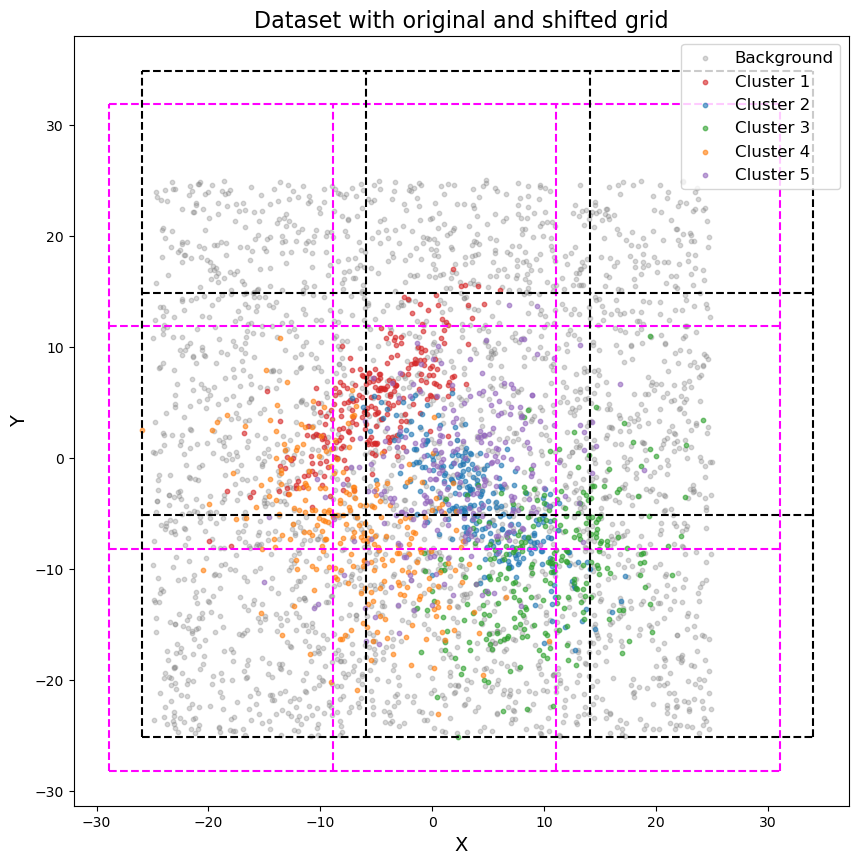

In [41]:
grid_size = 20 #10
shift_vector = [3, 3, 3]

# Define grid ranges
x_range1, y_range1, z_range1 = create_grid(df, grid_size, shift_vector, num_shifts=1)
x_range2, y_range2, z_range2 = shift_grid(x_range1, y_range1, z_range1, shift_vector)

plot_multiple_grids_with_dataset_2d(
    df, x_range1, y_range1, z_range1, x_range2, y_range2, z_range2, 
    labels, colors, alphas, zorders, projection='xy', 
    title="Dataset with original and shifted grid"
)

# Rerun grid-based clustering and consensus clustering on points from a specific detected cluster, including background points

In [43]:
def rerun_clustering_on_detected_cluster_with_background(df, dist_matrix, true_labels, detected_cluster_id, consensus_labels, grid_size, shift_vector, K, num_rotations, num_shifts, projection, colors, solver='hbgf'):


    # Select points belonging only to specified detected cluster (including background points)
    cluster_indices = np.where(consensus_labels == detected_cluster_id)[0]  # Get matching indices
    subset_df = df.iloc[cluster_indices].reset_index(drop=True)
    subset_true_labels = true_labels[cluster_indices]
    subset_dist_matrix = dist_matrix[np.ix_(cluster_indices, cluster_indices)]

    # Check if there are enough points to proceed
    if len(subset_df) < 2:
        print(f"Detected cluster {detected_cluster_id}: Not enough points to run clustering.")
        return None, None, None, None, None

    print(f"Running clustering on detected cluster {detected_cluster_id}: {len(subset_df)} points (including background)")

    # Rerun grid-based clustering
    start_time = time.time()
    grid_results = grid_softmax_clustering(
        subset_df, subset_dist_matrix, grid_size, shift_vector, K, softmax_clustering_optimized, subset_true_labels,
        num_rotations=num_rotations, rotation_axis='z', rotation_angle=None, num_shifts=num_shifts, projection=projection, colors=colors
    )
    
    grid_time = time.time() - start_time

    # Rerun consensus clustering
    start_time = time.time()
    new_consensus_labels = consensus_clustering_from_grid(grid_results, solver=solver, nclass=K, random_state=42, verbose=False)
    consensus_time = time.time() - start_time

    # Ensure indices match length of new_consensus_labels
    subset_true_labels = subset_true_labels[:len(new_consensus_labels)]

    # Remove background points for NMI calculation
    non_background_indices = subset_true_labels != 0
    filtered_true_labels = subset_true_labels[non_background_indices]
    filtered_consensus_labels = np.array(new_consensus_labels)[non_background_indices]

    # Remap labels to correct range
    true_labels_encoded = LabelEncoder().fit_transform(filtered_true_labels)
    consensus_labels_encoded = LabelEncoder().fit_transform(filtered_consensus_labels)

    # calculate NMI
    nmi = normalized_mutual_info_score(true_labels_encoded, consensus_labels_encoded)

    print(f"Detected cluster {detected_cluster_id} Results:")
    print(f"  Grid time: {grid_time:.2f}s, Consensus time: {consensus_time:.2f}s")
    print(f"  NMI: {nmi:.4f}")

    return new_consensus_labels, subset_df, subset_true_labels, grid_time + consensus_time, nmi



Running clustering on detected cluster 8: 469 points (including background)
Rotation 1: No rotation
  Shift 1: Applying shift vector [2, 2, 2]


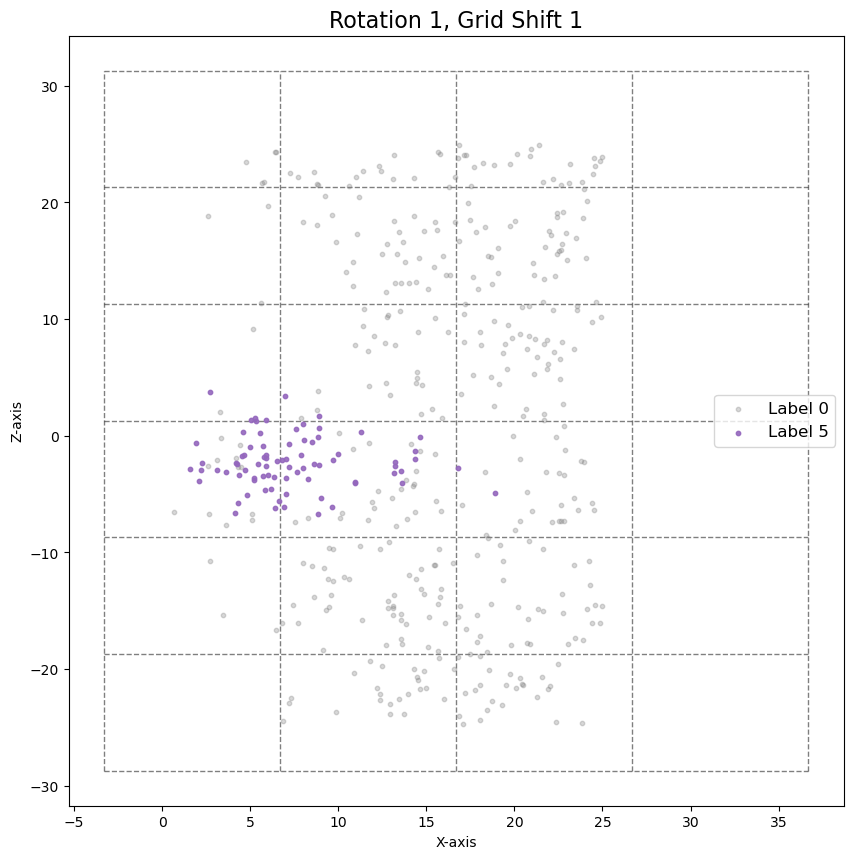

  Shift 2: Applying shift vector [2, 2, 2]
Rotation 2: Rotating by 180.00° around z-axis
  Shift 1: Applying shift vector [2, 2, 2]


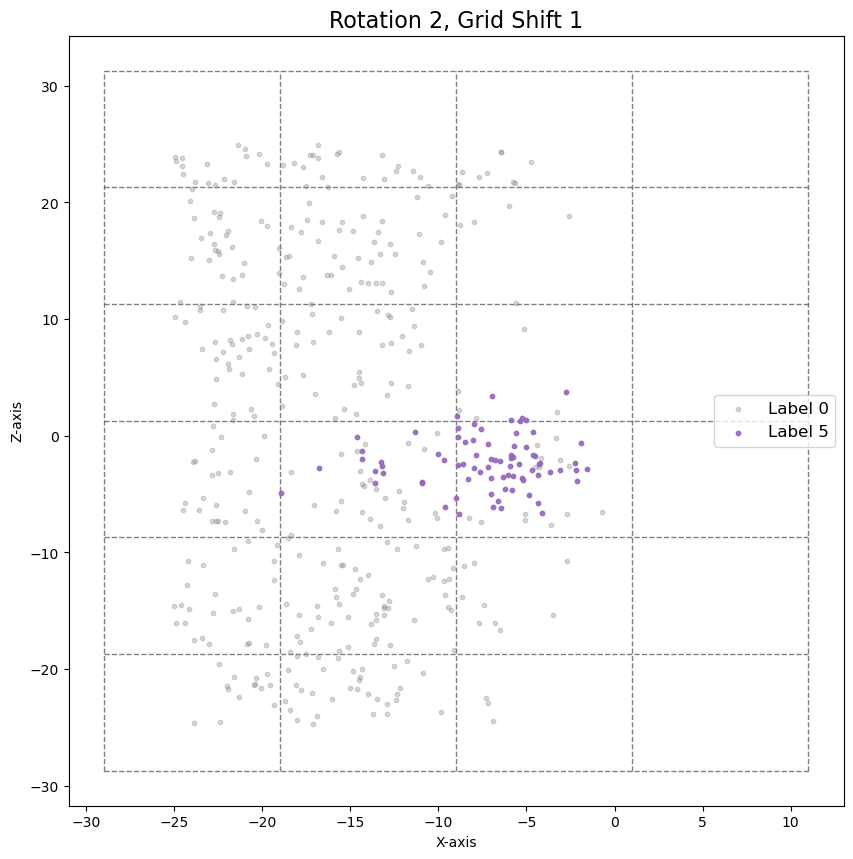

  Shift 2: Applying shift vector [2, 2, 2]
Detected cluster 8 Results:
  Grid time: 0.62s, Consensus time: 0.15s
  NMI: 0.0000


In [44]:
detected_cluster_id = 8

new_consensus_labels, subset_df, subset_true_labels, total_time, nmi = rerun_clustering_on_detected_cluster_with_background(
    df=df,
    dist_matrix=dist_matrix,
    true_labels=labels,
    detected_cluster_id=detected_cluster_id,
    consensus_labels=consensus_labels,
    grid_size=10,
    shift_vector=[2, 2, 2],
    K=4,
    num_rotations=2,
    num_shifts=2,
    projection='xz',
    colors = colors,
    solver='hbgf'
)

In [45]:
num_clusters = len(np.unique(new_consensus_labels))
nmi = calculate_nmi(new_consensus_labels, subset_true_labels, background_label=0)

In [46]:
overall_nmi = calculate_nmi_and_purity(new_consensus_labels, subset_true_labels, background_label=0)

Overall NMI (ignoring background points): 0.0000

Cluster 0:
  - Number of points: 148
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 71 points
    * True label 5.0: 77 points


Cluster 1:
  - Number of points: 111
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 110 points
    * True label 5.0: 1 points


Cluster 2: Only background points present.
  - Number of points: 101

Cluster 3:
  - Number of points: 109
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 108 points
    * True label 5.0: 1 points




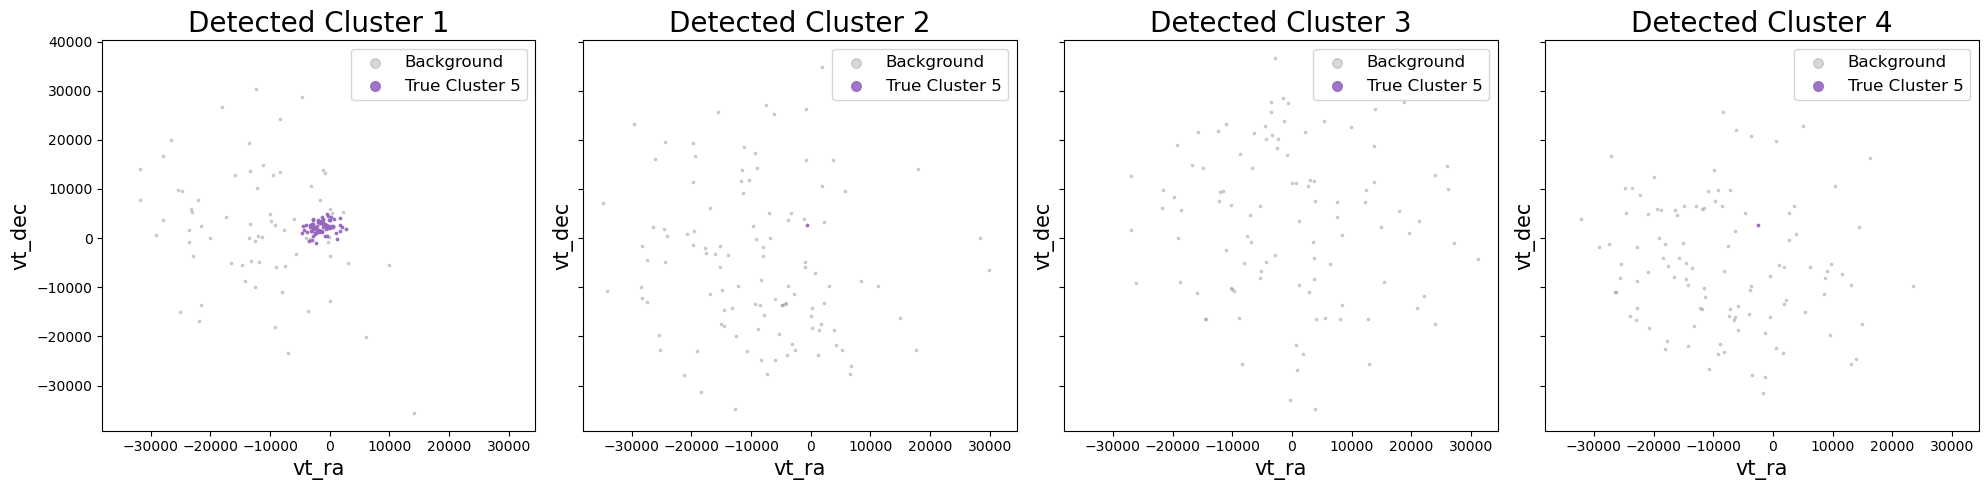

In [47]:
visualise_cluster_result(
    df=subset_df,
    cluster_labels=new_consensus_labels,
    true_labels=subset_true_labels,
    K=num_clusters,
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
    )

# Triangular grid

In [49]:
#  Check if given point is inside triangle using barycentric coordinates
def is_point_inside_triangle(point, triangle):

    x, y = point
    x1, y1 = triangle[0]
    x2, y2 = triangle[1]
    x3, y3 = triangle[2]

    denominator = (y2 - y3) * (x1 - x3) + (x3 - x2) * (y1 - y3)
    a = ((y2 - y3) * (x - x3) + (x3 - x2) * (y - y3)) / denominator
    b = ((y3 - y1) * (x - x3) + (x1 - x3) * (y - y3)) / denominator
    c = 1 - a - b

    return 0 <= a <= 1 and 0 <= b <= 1 and 0 <= c <= 1

In [50]:
# Create triangle grid, starting from rectangle
def create_triangular_grid(df, grid_size):
    x_min, x_max = df['x'].min(), df['x'].max()
    y_min, y_max = df['y'].min(), df['y'].max()

    x_min -= grid_size
    x_max += grid_size
    y_min -= grid_size
    y_max += grid_size

    x_range = np.arange(x_min, x_max + grid_size, grid_size)
    y_range = np.arange(y_min, y_max + grid_size * np.sqrt(3) / 2, grid_size * np.sqrt(3) / 2)

    triangles = []
    for j, y in enumerate(y_range):
        for i, x in enumerate(x_range):
            x_offset = 0 if j % 2 == 0 else grid_size / 2
            triangles.append([(x + x_offset, y),
                              (x + x_offset + grid_size / 2, y + grid_size * np.sqrt(3) / 2),
                              (x + x_offset - grid_size / 2, y + grid_size * np.sqrt(3) / 2)])
            triangles.append([(x + x_offset, y),
                              (x + x_offset + grid_size / 2, y - grid_size * np.sqrt(3) / 2),
                              (x + x_offset - grid_size / 2, y - grid_size * np.sqrt(3) / 2)])

    return triangles

In [51]:
def partition_points_into_triangles(df, triangles):

    grid_partitions = {tuple(map(tuple, triangle)): [] for triangle in triangles}

    for i, row in df.iterrows():
        x, y = row['x'], row['y']
        for triangle in triangles:
            if is_point_inside_triangle((x, y), triangle):
                grid_partitions[tuple(map(tuple, triangle))].append(i)
                break

    return grid_partitions

In [52]:
#Rotate triangular grid around given center by specified angle
def rotate_triangular_grid(triangles, angle_degrees, center=(0, 0)):
    
    angle_radians = np.radians(angle_degrees)
    cos_theta, sin_theta = np.cos(angle_radians), np.sin(angle_radians)
    cx, cy = center

    rotated_triangles = []
    for triangle in triangles:
        rotated_triangle = []
        for x, y in triangle:
            # Translate point to origin
            x -= cx
            y -= cy
            # Rotate point
            x_rot = x * cos_theta - y * sin_theta
            y_rot = x * sin_theta + y * cos_theta
            # Translate point back
            x_rot += cx
            y_rot += cy
            rotated_triangle.append((x_rot, y_rot))
        rotated_triangles.append(rotated_triangle)
    return rotated_triangles


In [53]:
def plot_triangular_grid(df, triangles, true_labels, colors, alphas, zorders, projection='xz', title="Dataset with triangular grid"):
 
    points = df[['x', 'z']].values if projection == 'xz' else df[['x', 'y']].values
    true_labels = true_labels.astype(int)

    background_color = colors[-1]
    background_alpha = alphas[-1]
    background_zorder = zorders[-1]

    cluster_colors = colors[:-1]
    cluster_alphas = alphas[:-1]
    cluster_zorders = zorders[:-1]

    unique_labels = np.unique(true_labels)
    label_to_color = {}
    label_to_alpha = {}
    label_to_zorder = {}

    for label in unique_labels:
        if label == 0:
            label_to_color[label] = background_color
            label_to_alpha[label] = background_alpha
            label_to_zorder[label] = background_zorder
        else:
            cluster_idx = (label - 1) % len(cluster_colors)
            label_to_color[label] = cluster_colors[cluster_idx]
            label_to_alpha[label] = cluster_alphas[cluster_idx]
            label_to_zorder[label] = cluster_zorders[cluster_idx]

    fig, ax = plt.subplots(figsize=(10, 10))

    # dataset points
    for label in unique_labels:
        idx = true_labels == label
        ax.scatter(
            points[idx, 0],
            points[idx, 1],
            s=10,
            color=label_to_color[label],
            alpha=label_to_alpha[label],
            zorder=label_to_zorder[label],
            label=f'Label {label}'
        )

    # triangular grid
    for triangle in triangles:
        polygon = Polygon(triangle, closed=True, edgecolor='black', fill=None, linestyle='--', linewidth=1, alpha=0.5)
        ax.add_patch(polygon)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('X-axis' if projection == 'xz' else 'X-axis')
    ax.set_ylabel('Z-axis' if projection == 'xz' else 'Y-axis')
    ax.legend(fontsize=12)
    plt.show()

In [54]:
def grid_softmax_clustering_triangles(df, dist_matrix, grid_size, shift_vector, K, clustering_func, true_labels, colors, num_rotations=3, rotation_axis='z', rotation_angle=None, num_shifts=3, projection='xz', print_info = False):
   
    all_results = []

    if rotation_angle is None:
        rotation_angle = 360 / num_rotations if num_rotations > 1 else 0

    triangles = create_triangular_grid(df, grid_size)
    G = compute_g_matrix(dist_matrix)

    for rotation_step in range(num_rotations):
        if rotation_step == 0:
            rotated_triangles = triangles
            rotated_df = df
            print(f"Rotation {rotation_step + 1}: Using the initial dataset")
        else:
            angle = rotation_step * rotation_angle
            print(f"Rotation {rotation_step + 1}: Rotating dataset by {angle:.2f} degrees around {rotation_axis} axis")
            rotated_triangles = rotate_triangular_grid(triangles, angle)
            rotated_df = rotate_dataset(df, angle, axis=rotation_axis)

        for shift_step in range(num_shifts):
            print(f"  Shift {shift_step + 1}: Applying shift vector {shift_vector}")

            shifted_triangles = [
                [(x + shift_vector[0], y + shift_vector[1]) for x, y in triangle]
                for triangle in rotated_triangles
            ]

            grid_partitions = partition_points_into_triangles(rotated_df, shifted_triangles)

            label_offset = 0
            shift_results = []

            for cell_idx, (triangle, indices) in enumerate(grid_partitions.items()):
                if len(indices) == 0:
                    continue

                original_indices = np.array(indices)
                original_indices = original_indices[original_indices < dist_matrix.shape[0]]

                subset_G = G[np.ix_(original_indices, original_indices)]

                # softmax clustering
                p_i, _ = clustering_func(subset_G, K)

                cluster_assignments = np.argmax(p_i, axis=1)
                unique_clusters = np.unique(cluster_assignments)

                # Remap cluster labels sequentially across cells
                cluster_mapping = {cluster: label_offset + i for i, cluster in enumerate(unique_clusters)}
                remapped_labels = np.array([cluster_mapping[cluster] for cluster in cluster_assignments])
                label_offset += len(unique_clusters)

                shift_results.append((remapped_labels, original_indices))
                
                if print_info == True:
                    print(f"    Rotation {rotation_step + 1}, Shift {shift_step + 1}, Cell {cell_idx + 1}:")
                    print(f"      Number of clusters: {len(unique_clusters)}")
                    print(f"      Cluster labels: {np.unique(remapped_labels)}")

            all_results.append((rotation_step, shift_step, shift_results))


            if rotation_step == 0 and shift_step == 0:
                plot_triangular_grid(
                    rotated_df, shifted_triangles, true_labels, colors, alphas, zorders,
                    projection=projection, title=f"Rotation {rotation_step + 1}, Grid Shift {shift_step + 1}"
                )

    return all_results

In [55]:
def consensus_clustering_from_triangles(grid_results, solver='hbgf', nclass=None, random_state=None, verbose=False):

    all_labels = extract_labels_from_grid(grid_results)
    consensus_labels = CE.cluster_ensembles(all_labels, nclass=nclass, solver=solver, random_state=random_state, verbose=verbose)
    return consensus_labels

Rotation 1: Using the initial dataset
  Shift 1: Applying shift vector [2, 2, 2]


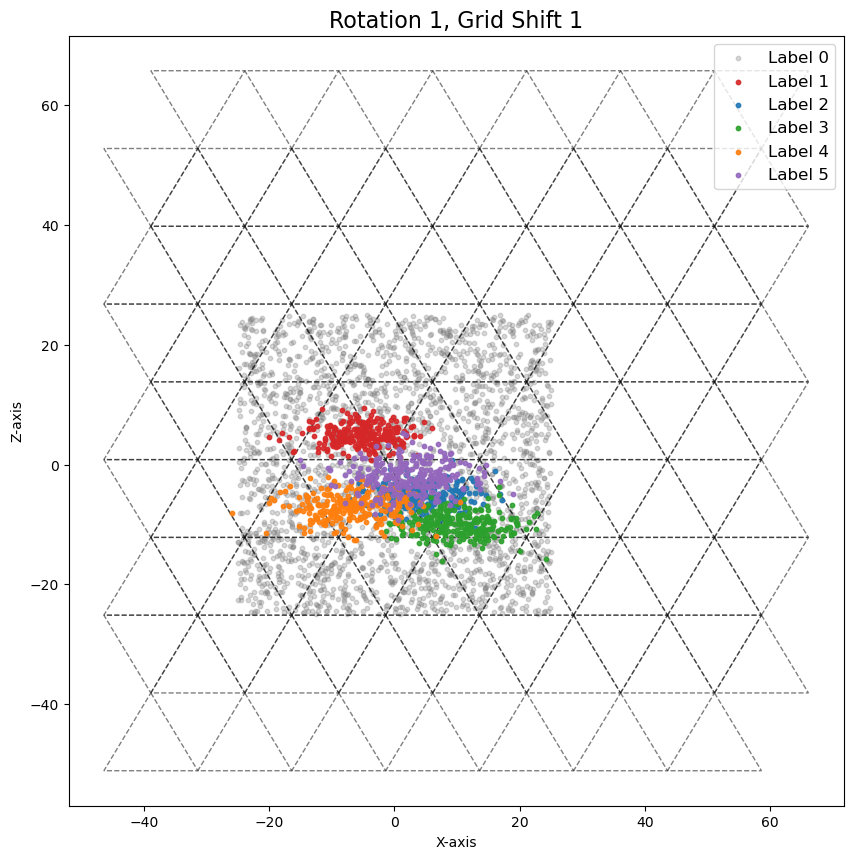

  Shift 2: Applying shift vector [2, 2, 2]
Rotation 2: Rotating dataset by 180.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]


In [56]:
grid_size = 15
shift_vector = [2, 2, 2]
num_rotations = 2
rotation_axis = 'z'
rotation_angle = None
num_shifts = 2
projection = 'xz'
K = 9
dist_matrix = dist_v_opt

# set print_info to True to print iformation about each rotation and each grid
grid_results = grid_softmax_clustering_triangles(
    df, dist_matrix, grid_size, shift_vector, K, softmax_clustering_optimized, labels, colors,
    num_rotations=num_rotations, rotation_axis=rotation_axis,
    rotation_angle=rotation_angle, num_shifts=num_shifts, projection=projection
)

In [57]:
consensus_labels = consensus_clustering_from_triangles(grid_results, solver='hbgf', nclass=K, random_state=42, verbose=True)

Cluster Ensembles
    - number of classes: 9
    - solver: hbgf
    - length of base clustering labels: 3750
    - number of base clusters: 4


In [58]:
nmi = calculate_nmi(consensus_labels, labels, background_label=0)

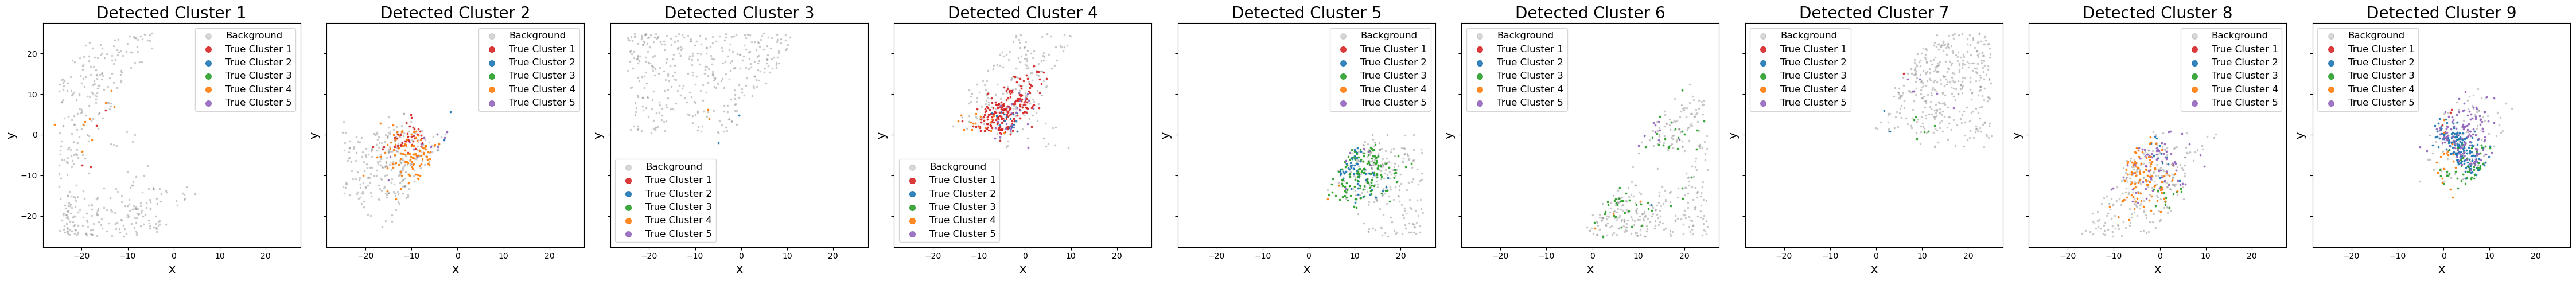

In [59]:
visualise_cluster_result(
    df=df,
    cluster_labels=consensus_labels,
    true_labels=labels,
    K=len(np.unique(consensus_labels)),  
    x_col='x',
    y_col='y',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

# Compare different configuration

In [61]:
def trying_different_configurations(
    df, labels, dist_matrix, grid_sizes, shift_vectors, num_rotations_list,
    num_shifts_list, solvers, K, colors, rotation_axis='z', projection='xz', background_label=0, grid_method="square"
):
    results = []  # results for each configuration

    # Iterate over all combinations of parameters
    option_num = 1
    for grid_size in grid_sizes:
        for shift_vector in shift_vectors:
            for num_rotations in num_rotations_list:
                for num_shifts in num_shifts_list:
                    for solver in solvers:
                        print(f"Option {option_num}:")
                        print(f"  Grid Size: {grid_size}, Shift Vector: {shift_vector}, "
                              f"Rotations: {num_rotations}, Shifts: {num_shifts}, Solver: {solver}")
                        
                        # Start timing grid softmax clustering
                        grid_start_time = time.time()
                        
                        # Choose clustering function based on grid type
                        if grid_method == "square":
                            grid_results = grid_softmax_clustering(
                                df, dist_matrix, grid_size, shift_vector, K, softmax_clustering_optimized, labels,
                                num_rotations=num_rotations, rotation_axis=rotation_axis,
                                rotation_angle=None, num_shifts=num_shifts, projection=projection, colors = colors
                            )

                        elif grid_method == "triangular":
                            grid_results = grid_softmax_clustering_triangles(
                                df, dist_matrix, grid_size, shift_vector, K, softmax_clustering_optimized, labels,
    num_rotations=num_rotations, rotation_axis=rotation_axis,
    rotation_angle=rotation_angle, num_shifts=num_shifts, projection=projection, colors = colors
                            )
                        else:
                            raise ValueError("Unsupported grid method. Use 'square' or 'triangular'.")
                        
                        grid_end_time = time.time()

                        # Start timing consensus clustering
                        consensus_start_time = time.time()
                        
                        if grid_method == "square":
                            consensus_labels = consensus_clustering_from_grid(
                                grid_results, solver=solver, nclass=K, random_state=42, verbose=False
                            )
                        elif grid_method == "triangular":
                            consensus_labels = consensus_clustering_from_triangles(
                                grid_results, solver=solver, nclass=K, random_state=42, verbose=False
                            )
                        
                        consensus_end_time = time.time()

                        # total times
                        grid_time = grid_end_time - grid_start_time
                        consensus_time = consensus_end_time - consensus_start_time

                        # NMI
                        nmi = calculate_nmi(consensus_labels, labels, background_label)

                        # Save results
                        results.append({
                            "option": option_num,
                            "parameters": {
                                "grid_size": grid_size,
                                "shift_vector": shift_vector,
                                "num_rotations": num_rotations,
                                "num_shifts": num_shifts,
                                "solver": solver,
                                "grid_method": grid_method
                            },
                            "consensus_labels": consensus_labels,
                            "nmi": nmi,
                            "grid_time": grid_time,
                            "consensus_time": consensus_time,
                            "total_time": grid_time + consensus_time,
                        })

                        # summary for current option
                        print(f"  NMI: {nmi:.4f}, Grid Time: {grid_time:.2f}s, Consensus Time: {consensus_time:.2f}s, "
                              f"Total Time: {grid_time + consensus_time:.2f}s\n")

                        option_num += 1

    return results

Option 1:
  Grid Size: 5, Shift Vector: [2, 2, 2], Rotations: 3, Shifts: 5, Solver: cspa
Rotation 1: No rotation
  Shift 1: Applying shift vector [2, 2, 2]


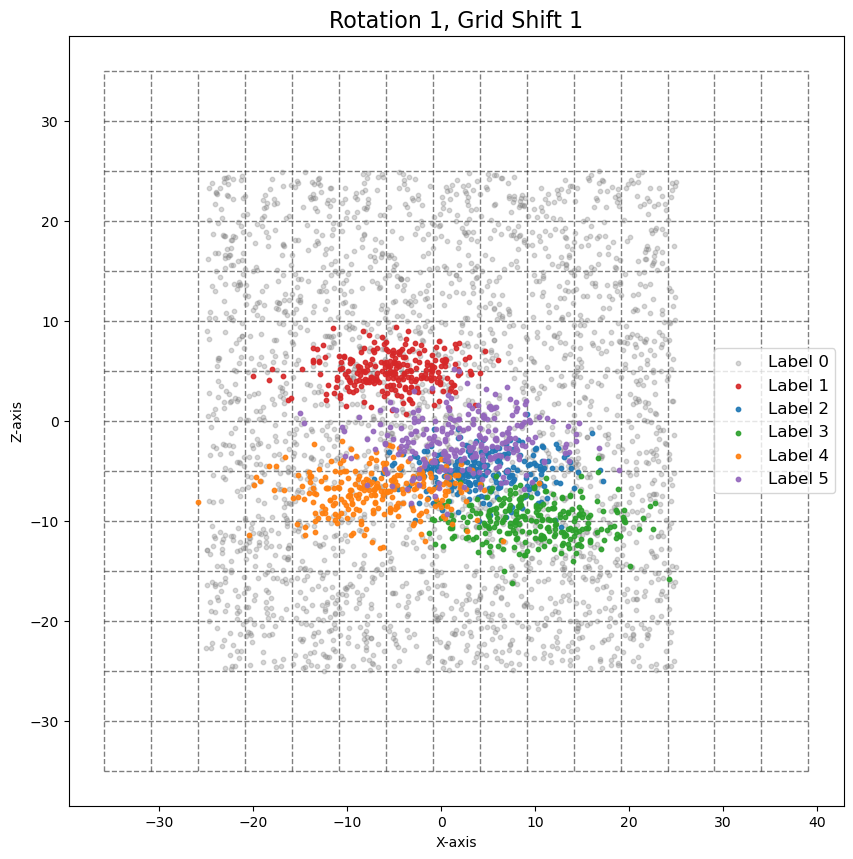

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
Rotation 2: Rotating by 120.00° around z-axis
  Shift 1: Applying shift vector [2, 2, 2]


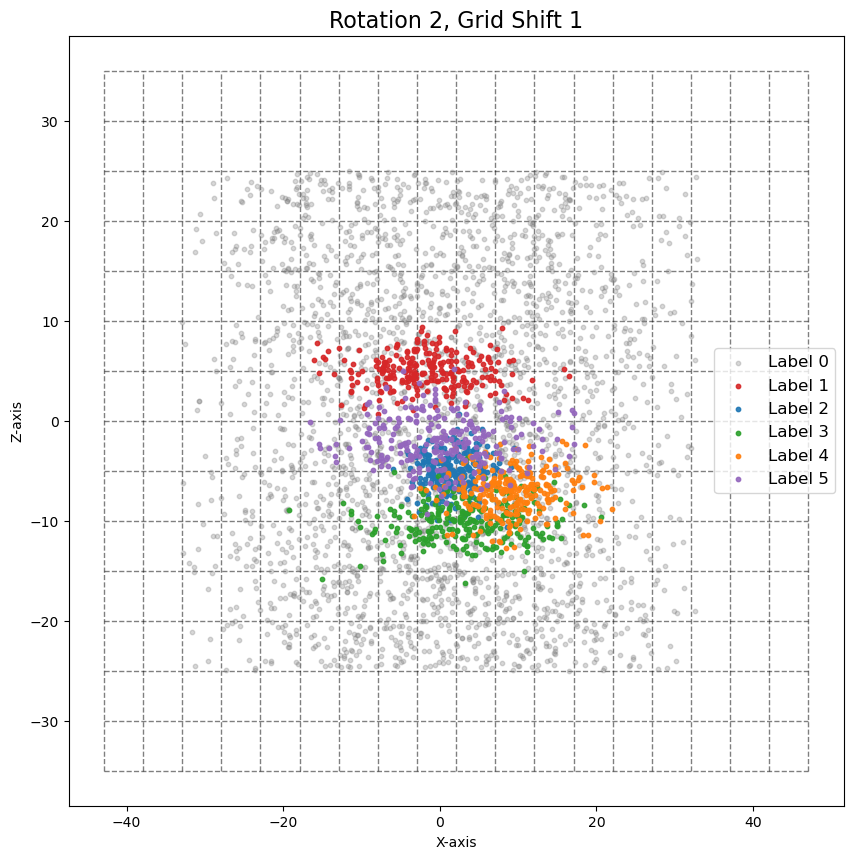

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
Rotation 3: Rotating by 240.00° around z-axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
  NMI: 0.5243, Grid Time: 31.41s, Consensus Time: 2.09s, Total Time: 33.49s

Option 2:
  Grid Size: 10, Shift Vector: [2, 2, 2], Rotations: 3, Shifts: 5, Solver: cspa
Rotation 1: No rotation
  Shift 1: Applying shift vector [2, 2, 2]


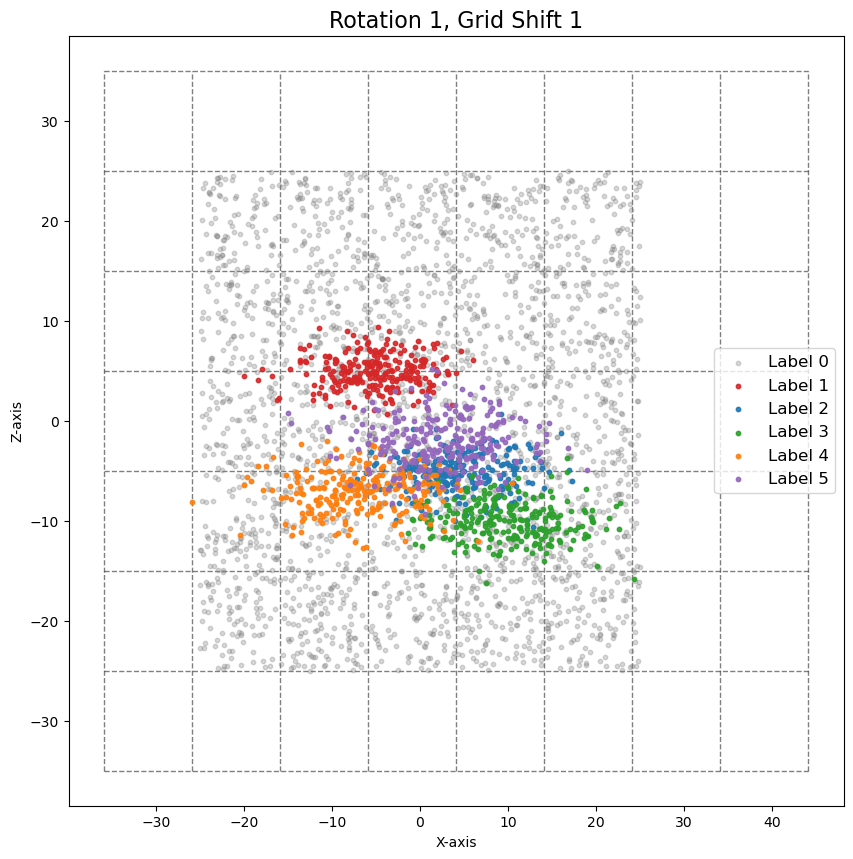

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
Rotation 2: Rotating by 120.00° around z-axis
  Shift 1: Applying shift vector [2, 2, 2]


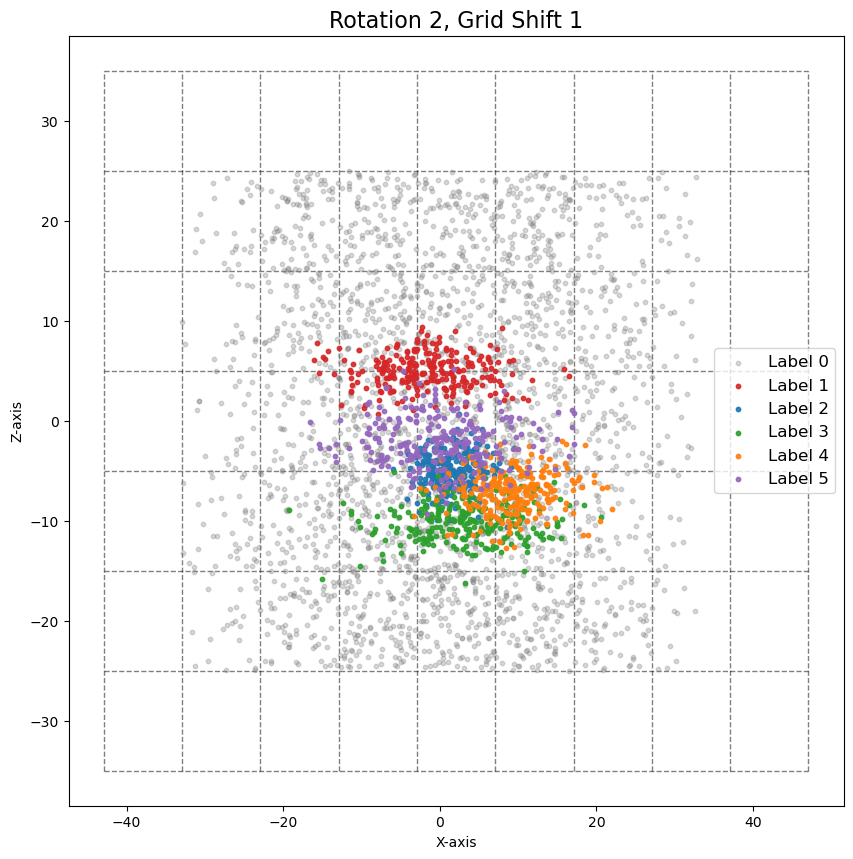

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
Rotation 3: Rotating by 240.00° around z-axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
  NMI: 0.5550, Grid Time: 8.91s, Consensus Time: 8.21s, Total Time: 17.12s

Option 3:
  Grid Size: 15, Shift Vector: [2, 2, 2], Rotations: 3, Shifts: 5, Solver: cspa
Rotation 1: No rotation
  Shift 1: Applying shift vector [2, 2, 2]


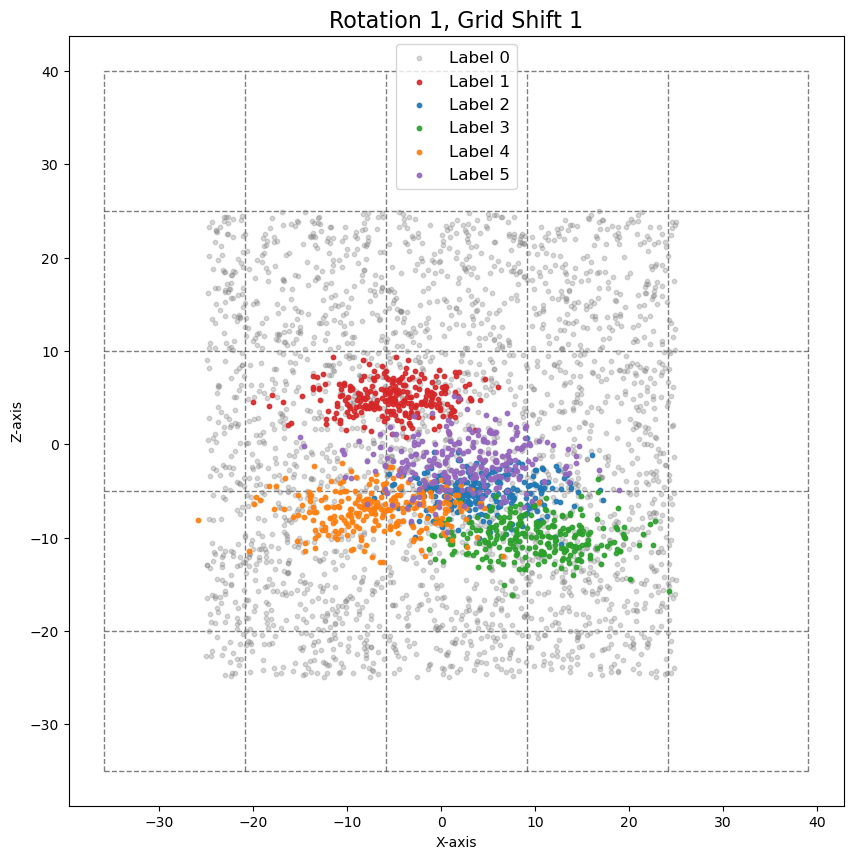

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
Rotation 2: Rotating by 120.00° around z-axis
  Shift 1: Applying shift vector [2, 2, 2]


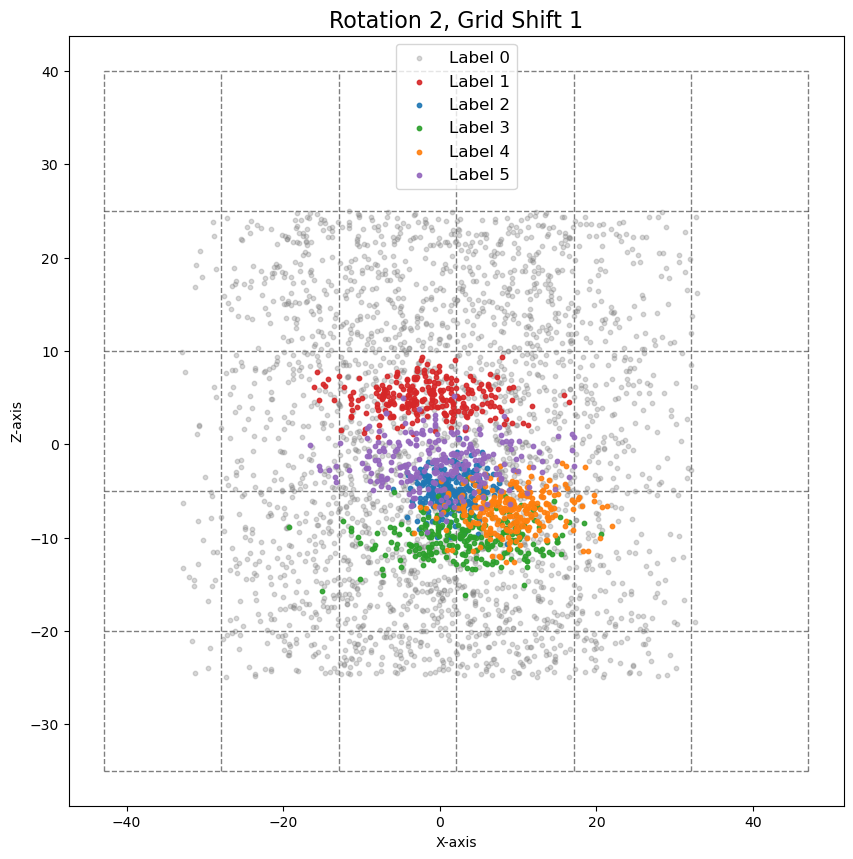

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
Rotation 3: Rotating by 240.00° around z-axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  Shift 4: Applying shift vector [2, 2, 2]
  Shift 5: Applying shift vector [2, 2, 2]
  NMI: 0.5740, Grid Time: 7.13s, Consensus Time: 15.54s, Total Time: 22.67s



In [62]:
# parameter combinations for square grid
grid_sizes = [5, 10, 15]
shift_vectors = [[2, 2, 2]]
num_rotations_list = [3]
num_shifts_list = [5]
solvers = ['cspa']

results = trying_different_configurations(
    df=df,
    labels=labels,
    dist_matrix=dist_v_opt,
    grid_sizes=grid_sizes,
    shift_vectors=shift_vectors,
    num_rotations_list=num_rotations_list,
    num_shifts_list=num_shifts_list,
    solvers=solvers,
    K=9,
    colors=colors,
    rotation_axis='z',
    projection='xz',
    background_label=0,
    grid_method="square"  
)

In [63]:
# summary of all options
for result in results:
    print(f"Option {result['option']}:")
    print(f"  Parameters: {result['parameters']}")
    print(f"  NMI: {result['nmi']:.4f}")
    print(f"  Grid Time: {result['grid_time']:.2f}s")
    print(f"  Consensus Time: {result['consensus_time']:.2f}s")
    print(f"  Total Time: {result['total_time']:.2f}s\n")

Option 1:
  Parameters: {'grid_size': 5, 'shift_vector': [2, 2, 2], 'num_rotations': 3, 'num_shifts': 5, 'solver': 'cspa', 'grid_method': 'square'}
  NMI: 0.5243
  Grid Time: 31.41s
  Consensus Time: 2.09s
  Total Time: 33.49s

Option 2:
  Parameters: {'grid_size': 10, 'shift_vector': [2, 2, 2], 'num_rotations': 3, 'num_shifts': 5, 'solver': 'cspa', 'grid_method': 'square'}
  NMI: 0.5550
  Grid Time: 8.91s
  Consensus Time: 8.21s
  Total Time: 17.12s

Option 3:
  Parameters: {'grid_size': 15, 'shift_vector': [2, 2, 2], 'num_rotations': 3, 'num_shifts': 5, 'solver': 'cspa', 'grid_method': 'square'}
  NMI: 0.5740
  Grid Time: 7.13s
  Consensus Time: 15.54s
  Total Time: 22.67s



Option 1:
  Grid Size: 5, Shift Vector: [2, 2, 2], Rotations: 3, Shifts: 2, Solver: cspa
Rotation 1: Using the initial dataset
  Shift 1: Applying shift vector [2, 2, 2]


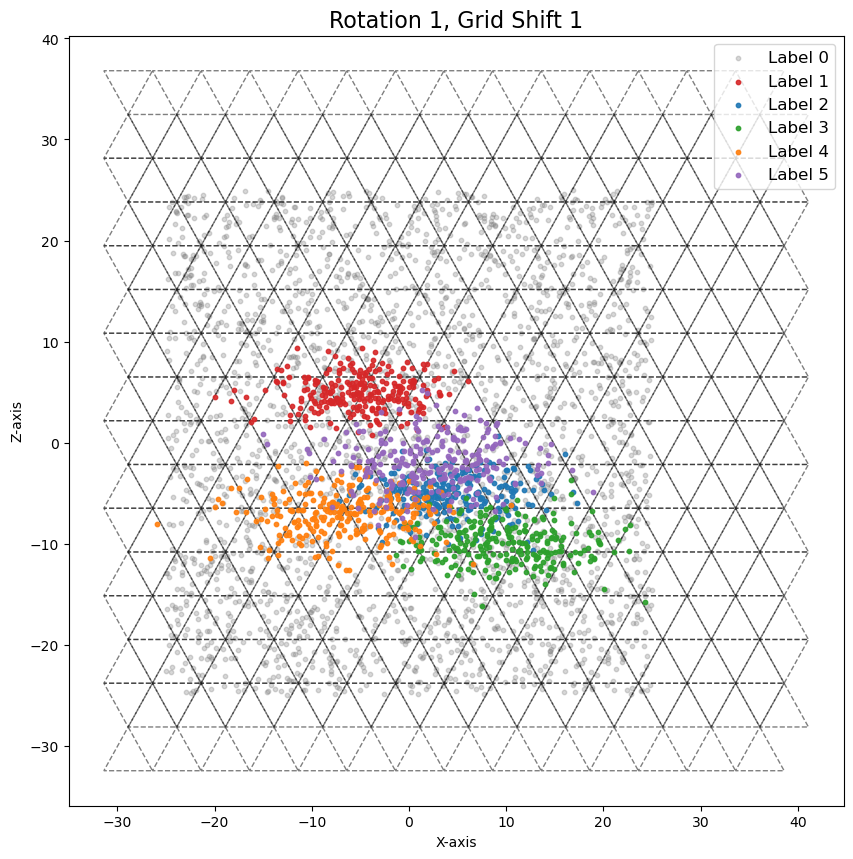

  Shift 2: Applying shift vector [2, 2, 2]
Rotation 2: Rotating dataset by 120.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
Rotation 3: Rotating dataset by 240.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  NMI: 0.3613, Grid Time: 5.83s, Consensus Time: 1.69s, Total Time: 7.52s

Option 2:
  Grid Size: 5, Shift Vector: [2, 2, 2], Rotations: 3, Shifts: 2, Solver: hbgf
Rotation 1: Using the initial dataset
  Shift 1: Applying shift vector [2, 2, 2]


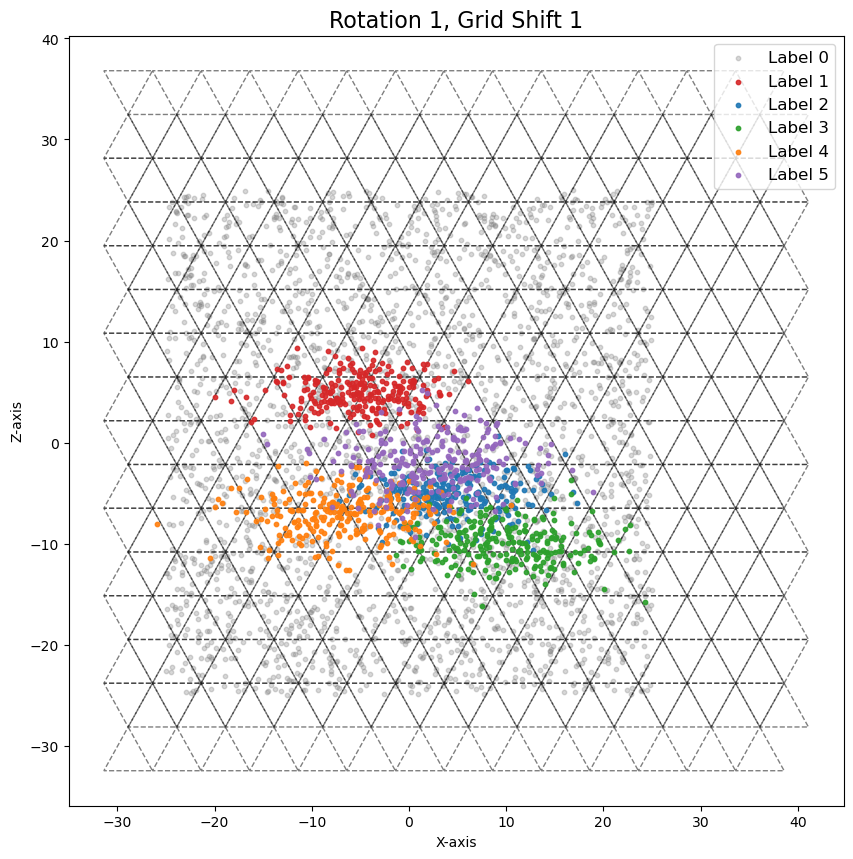

  Shift 2: Applying shift vector [2, 2, 2]
Rotation 2: Rotating dataset by 120.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
Rotation 3: Rotating dataset by 240.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  NMI: 0.2759, Grid Time: 5.78s, Consensus Time: 2.25s, Total Time: 8.03s

Option 3:
  Grid Size: 5, Shift Vector: [2, 2, 2], Rotations: 3, Shifts: 3, Solver: cspa
Rotation 1: Using the initial dataset
  Shift 1: Applying shift vector [2, 2, 2]


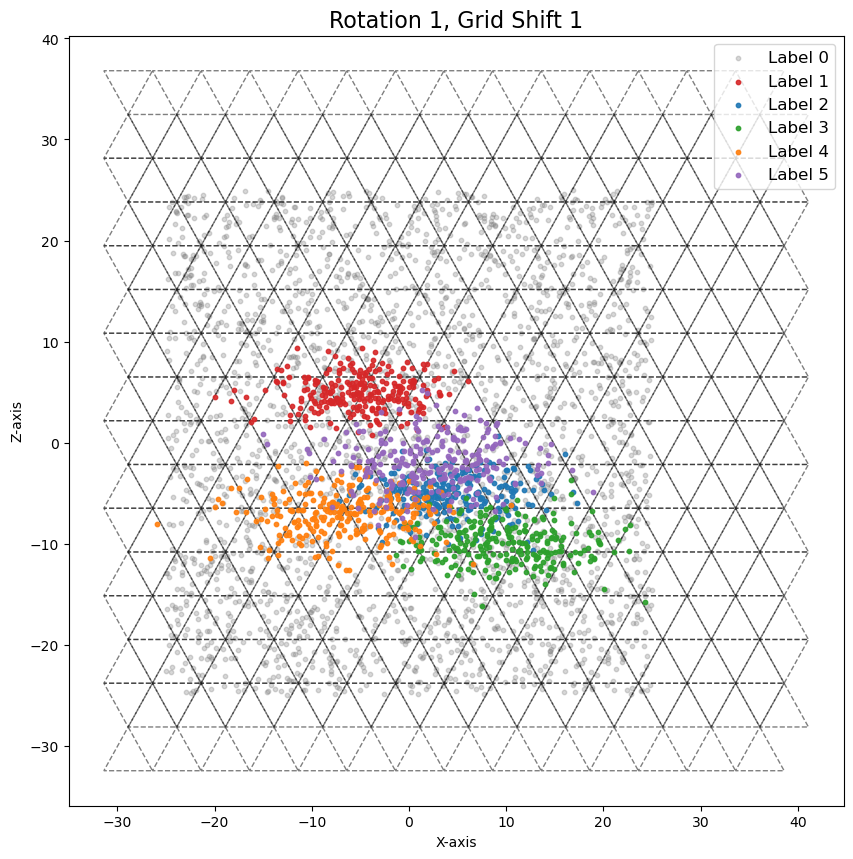

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
Rotation 2: Rotating dataset by 120.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
Rotation 3: Rotating dataset by 240.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  NMI: 0.3613, Grid Time: 8.35s, Consensus Time: 1.65s, Total Time: 10.00s

Option 4:
  Grid Size: 5, Shift Vector: [2, 2, 2], Rotations: 3, Shifts: 3, Solver: hbgf
Rotation 1: Using the initial dataset
  Shift 1: Applying shift vector [2, 2, 2]


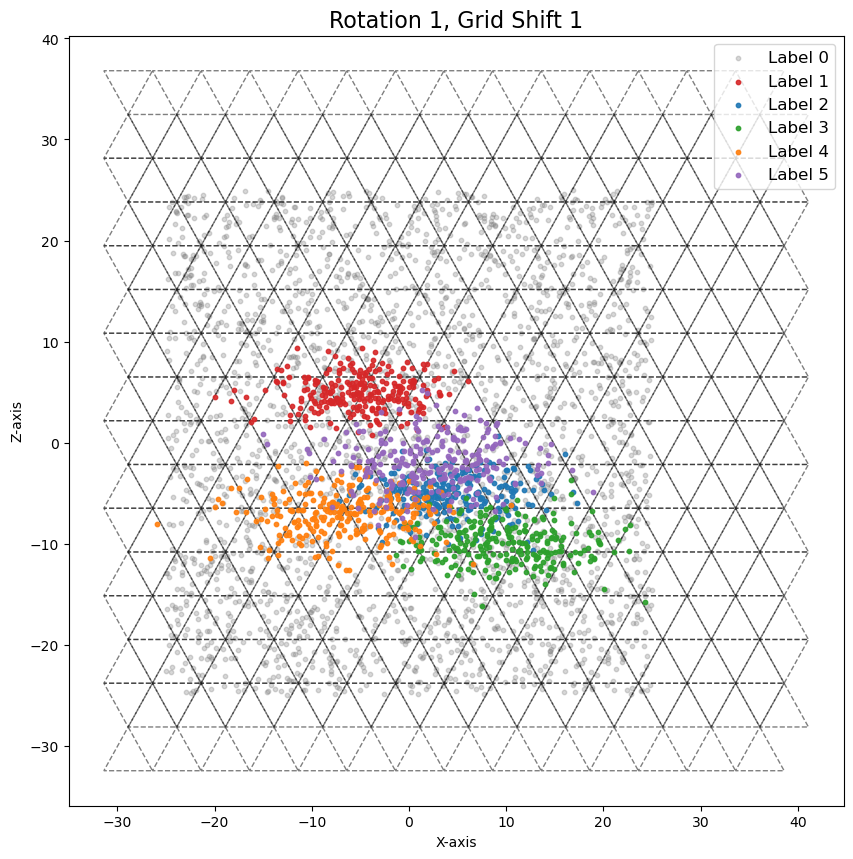

  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
Rotation 2: Rotating dataset by 120.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
Rotation 3: Rotating dataset by 240.00 degrees around z axis
  Shift 1: Applying shift vector [2, 2, 2]
  Shift 2: Applying shift vector [2, 2, 2]
  Shift 3: Applying shift vector [2, 2, 2]
  NMI: 0.3393, Grid Time: 8.38s, Consensus Time: 3.98s, Total Time: 12.36s



In [64]:
# parameter combinations for triangular grid
grid_sizes = [5]
shift_vectors = [[2, 2, 2]]
num_rotations_list = [3]
num_shifts_list = [2, 3]
solvers = ['cspa', 'hbgf']

results = trying_different_configurations(
    df=df,
    labels=labels,
    dist_matrix=dist_v_opt,
    grid_sizes=grid_sizes,
    shift_vectors=shift_vectors,
    num_rotations_list=num_rotations_list,
    num_shifts_list=num_shifts_list,
    solvers=solvers,
    K=9,
    colors=colors,
    rotation_axis='z',
    projection='xz',
    background_label=0,
    grid_method="triangular"  
)


In [65]:
# summary of all options
for result in results:
    print(f"Option {result['option']}:")
    print(f"  Parameters: {result['parameters']}")
    print(f"  NMI: {result['nmi']:.4f}")
    print(f"  Grid Time: {result['grid_time']:.2f}s")
    print(f"  Consensus Time: {result['consensus_time']:.2f}s")
    print(f"  Total Time: {result['total_time']:.2f}s\n")

Option 1:
  Parameters: {'grid_size': 5, 'shift_vector': [2, 2, 2], 'num_rotations': 3, 'num_shifts': 2, 'solver': 'cspa', 'grid_method': 'triangular'}
  NMI: 0.3613
  Grid Time: 5.83s
  Consensus Time: 1.69s
  Total Time: 7.52s

Option 2:
  Parameters: {'grid_size': 5, 'shift_vector': [2, 2, 2], 'num_rotations': 3, 'num_shifts': 2, 'solver': 'hbgf', 'grid_method': 'triangular'}
  NMI: 0.2759
  Grid Time: 5.78s
  Consensus Time: 2.25s
  Total Time: 8.03s

Option 3:
  Parameters: {'grid_size': 5, 'shift_vector': [2, 2, 2], 'num_rotations': 3, 'num_shifts': 3, 'solver': 'cspa', 'grid_method': 'triangular'}
  NMI: 0.3613
  Grid Time: 8.35s
  Consensus Time: 1.65s
  Total Time: 10.00s

Option 4:
  Parameters: {'grid_size': 5, 'shift_vector': [2, 2, 2], 'num_rotations': 3, 'num_shifts': 3, 'solver': 'hbgf', 'grid_method': 'triangular'}
  NMI: 0.3393
  Grid Time: 8.38s
  Consensus Time: 3.98s
  Total Time: 12.36s

